In [ ]:
# import sys
# !{sys.executable} -m pip install xgboost --no-deps

In [ ]:
# from xgboost import XGBRegressor
# print("xgboost ready")

In [ ]:
# !ls /home/dph207/.local/lib/python3.11/site-packages/ | grep -iE "numpy|scipy"

In [ ]:
# !rm -rf /home/dph207/.local/lib/python3.11/site-packages/numpy
# !rm -rf /home/dph207/.local/lib/python3.11/site-packages/numpy-*.dist-info
# !rm -rf /home/dph207/.local/lib/python3.11/site-packages/numpy.libs
# !rm -rf /home/dph207/.local/lib/python3.11/site-packages/scipy
# !rm -rf /home/dph207/.local/lib/python3.11/site-packages/scipy-*.dist-info
# !rm -rf /home/dph207/.local/lib/python3.11/site-packages/scipy.libs

In [ ]:
# !ls /home/dph207/.local/lib/python3.11/site-packages/ | grep -iE "numpy|scipy"

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# import matplotlib.pyplot as plt
# from sklearn.linear_model import Lasso
# from sklearn.linear_model import Ridge


# np.random.seed(42)

# # 1. Monthly date index
# dates = pd.date_range(start="1960-01-01", end="2015-12-31", freq="ME")
# n = len(dates)

# # Helper: AR(1) generator
# def ar1(phi, sigma, n, mu=0):
#     eps = np.random.normal(0, sigma, n)
#     x = np.zeros(n)
#     x[0] = mu
#     for t in range(1, n):
#         x[t] = mu + phi * x[t-1] + eps[t]
#     return x

# # 2. CPI LEVEL (not inflation)
# # CPI is usually trending upward, so we simulate a random walk with drift
# cpi = np.cumsum(np.random.normal(0.2, 0.1, n)) + 100

# # 3. Predictors (similar structure to FRED-MD)
# oil_price = ar1(0.6, 1.0, n, mu=50)
# interest_rate = ar1(0.8, 0.3, n, mu=3)
# unemployment = ar1(0.9, 0.1, n, mu=5)
# gdp_growth = np.sin(np.arange(n)/12) + np.random.normal(0, 0.2, n)
# exchange_rate = np.cumsum(np.random.normal(0, 0.5, n)) + 100
# commodity_index = np.cumsum(np.random.normal(0, 0.2, n)) + 200
# housing_starts = 100 + 10*np.sin(np.arange(n)/6) + np.random.normal(0, 2, n)
# credit_spread = ar1(0.7, 0.2, n, mu=1)
# stock_returns = np.random.normal(0, 2, n)
# money_supply = np.cumsum(np.random.normal(0.1, 0.05, n)) + 500
# consumer_sentiment = ar1(0.95, 0.05, n, mu=90)
# industrial_production = 50 + 5*np.sin(np.arange(n)/4) + np.random.normal(0, 1, n)

# # 4. Combine into DataFrame
# df = pd.DataFrame({
#     "date": dates,
#     "CPI": cpi,  # raw CPI level
#     "oil_price": oil_price,
#     "interest_rate": interest_rate,
#     "unemployment": unemployment,
#     "gdp_growth": gdp_growth,
#     "exchange_rate": exchange_rate,
#     "commodity_index": commodity_index,
#     "housing_starts": housing_starts,
#     "credit_spread": credit_spread,
#     "stock_returns": stock_returns,
#     "money_supply": money_supply,
#     "consumer_sentiment": consumer_sentiment,
#     "industrial_production": industrial_production
# })

# df


In [ ]:
import numpy as np
import pandas as pd

# Load the raw FRED-MD vintage (2026-05)
raw = pd.read_csv("2026-05-MD.csv")

# Row 0 of the data is the special "Transform:" row holding the tcodes.
# Build the official tcode map: {variable name -> tcode (1-7)}
tcode_map = raw.iloc[0, 1:].astype(int).to_dict()

# Everything below row 0 is the actual monthly data
df = raw.iloc[1:].copy()

# Parse dates (format like 1/1/1959) and set as index
df["sasdate"] = pd.to_datetime(df["sasdate"], format="%m/%d/%Y")
df = df.set_index("sasdate").astype(float)

print("Raw data:", df.shape, "| from", df.index[0].date(), "to", df.index[-1].date())

Raw data: (808, 126) | from 1959-01-01 to 2026-04-01


In [ ]:
# Start: Jan 1960 (drop 1959, following Medeiros et al. 2021)
# End:   Sep 2025 (last month before the Oct 2025 government shutdown,
#         which left missing values in CPI and 20 other series)
SAMPLE_START = "1960-01-01"
SAMPLE_END   = "2025-09-01"

df = df.loc[SAMPLE_START:SAMPLE_END]
print("Sample window:", df.shape)

Sample window: (789, 126)


In [ ]:
# Medeiros et al. (2021): "only variables with all observations
# in the sample period are used". No imputation.
n_before = df.shape[1]
df = df.dropna(axis=1)
print(f"Variables: {n_before} -> {df.shape[1]} (dropped {n_before - df.shape[1]} incomplete series)")
print(df.shape)

Variables: 126 -> 119 (dropped 7 incomplete series)
(789, 119)


In [ ]:
# # Drop rows with missing CPI
# df = df.dropna(subset=["CPI"])

# df["inflation"] = np.log(df["CPI"]).diff()

# # Remove CPI column after computing Inflation
# # because the series of CPI will become similar to inflation after tcode = 5 (Δlog), avoiding 2 identical columns into the predictor matrix.
# df = df.drop(columns=["CPI"])

# # Drop the first row (NaN from differencing)
# df = df.dropna(subset=["inflation"])

# # Keep only columns/ variables with NO missing values
# df = df.dropna(axis = 1)

# df

In [ ]:
# Monthly inflation: pi_t = log(P_t) - log(P_t-1), P = CPIAUCSL
df["inflation"] = np.log(df["CPIAUCSL"]).diff()

# NOTE: unlike the simulated data, we do NOT drop CPIAUCSL here.
# Its official tcode is 6 (delta-squared log), so its transformed
# version is the CHANGE in inflation -- not a duplicate of inflation.
# Medeiros et al. keep all variables as predictors.

In [ ]:
def stationarity_transform(x, tcode):
    """
    Apply FRED-MD transformation based on tcode.
    """
    if tcode == 1:   # no transformation
        return x

    if tcode == 2:   # Δx
        return x.diff()

    if tcode == 3:   # Δ²x
        return x.diff().diff()

    if tcode == 4:   # log(x)
        return np.log(x)

    if tcode == 5:   # Δlog(x)
        return np.log(x).diff()

    if tcode == 6:   # Δ²log(x)
        return np.log(x).diff().diff()

    if tcode == 7:   # Δ(x_t / x_{t-1} - 1)
        return (x / x.shift(1) - 1).diff()

    raise ValueError("Unknown tcode")


In [ ]:
# df_transformed = pd.DataFrame(index=df.index)
# for col in df.columns:
#     if col == "inflation":                 # target: already transformed
#         df_transformed[col] = df[col]
#     else:
#         tcode = tcode_map[col]             # official FRED-MD tcode, no .get() fallback
#         df_transformed[col] = stationarity_transform(df[col], tcode)

# # Drop the first 2 rows: tcode 6 (double differencing) creates 2 NaNs.
# # Sample effectively starts Mar 1960 -- same as McCracken & Ng (2016).
# df_transformed = df_transformed.dropna()
# print("Transformed:", df_transformed.shape, "| starts", df_transformed.index[0].date())

In [ ]:
df_transformed = pd.DataFrame(index=df.index)
cols = {}
for col in df.columns:
    if col == "inflation":
        cols[col] = df[col]
    else:
        cols[col] = stationarity_transform(df[col], tcode_map[col])

df_transformed = pd.concat(cols, axis=1).dropna()
print("Transformed:", df_transformed.shape, "| starts", df_transformed.index[0].date())

Transformed: (787, 120) | starts 1960-03-01


In [ ]:
def remove_outliers_mccracken_ng(df_t, exclude=("inflation",)):
    """McCracken & Ng (2016): set values >10 IQR from the median to NaN, then fill."""
    cleaned = df_t.copy()
    for col in cleaned.columns:
        if col in exclude:
            continue
        s = cleaned[col]
        med = s.median()
        iqr = s.quantile(0.75) - s.quantile(0.25)
        if iqr > 0:
            mask = (s - med).abs() > 10 * iqr
            s[mask] = np.nan
        cleaned[col] = s.ffill()   # carry last valid value forward
    return cleaned

df_transformed = remove_outliers_mccracken_ng(df_transformed)

In [ ]:
max_lag = 4
lag_frames = []
for lag in range(1, max_lag + 1):
    lagged = df_transformed.shift(lag)
    lagged.columns = [f"{col}_lag{lag}" for col in lagged.columns]
    lag_frames.append(lagged)

df_lags = pd.concat(lag_frames, axis=1)
df_lags["inflation"] = df_transformed["inflation"]   # contemporaneous target
df_lags["date"] = df_lags.index                       # keep date column for downstream code
df_lags = df_lags.dropna()

print("Final predictor matrix:", df_lags.shape)
print("Predictors:", df_lags.shape[1] - 2, "| obs from", df_lags['date'].iloc[0].date(), "to", df_lags['date'].iloc[-1].date())

Final predictor matrix: (783, 482)
Predictors: 480 | obs from 1960-07-01 to 2025-09-01


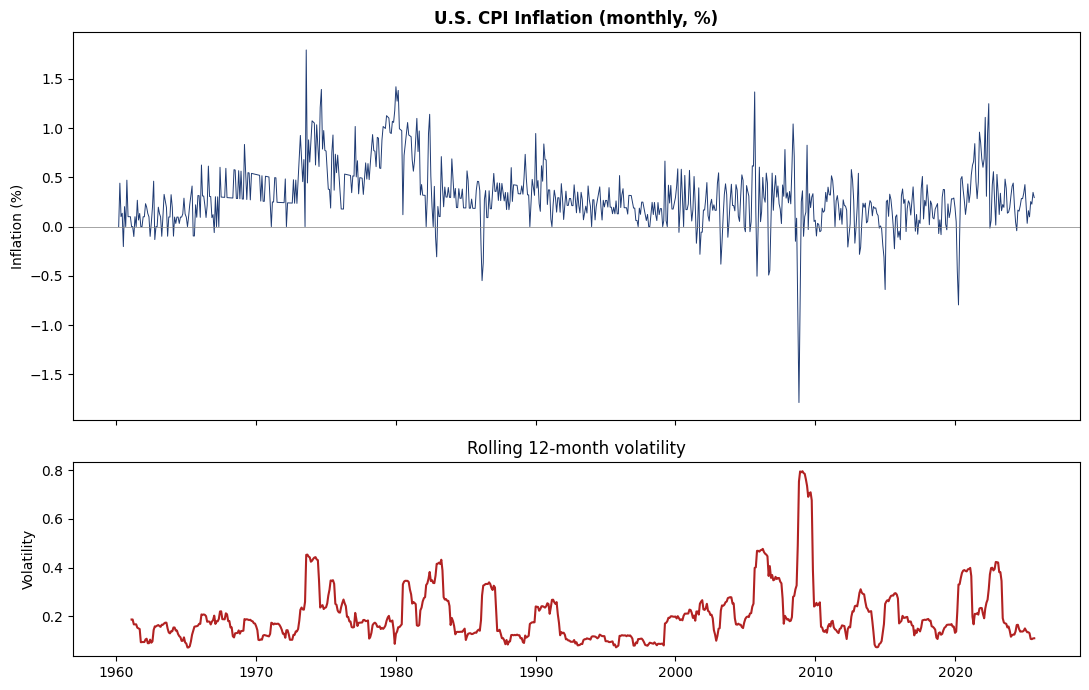

In [ ]:
import matplotlib.pyplot as plt

infl_pct = df_transformed["inflation"] * 100   # to percent for readability

fig, ax = plt.subplots(2, 1, figsize=(11, 7), height_ratios=[2, 1], sharex=True)
ax[0].plot(infl_pct.index, infl_pct.values, color="#1f3b73", lw=0.7)
ax[0].axhline(0, color="grey", lw=0.5)
ax[0].set_title("U.S. CPI Inflation (monthly, %)", fontweight="bold")
ax[0].set_ylabel("Inflation (%)")

roll_vol = infl_pct.rolling(12).std()
ax[1].plot(roll_vol.index, roll_vol.values, color="#b22222")
ax[1].set_title("Rolling 12-month volatility")
ax[1].set_ylabel("Volatility")
plt.tight_layout()
plt.show()

In [ ]:
infl = df_transformed["inflation"]
print("Full-sample summary (log-diff):")
print(infl.describe()[["mean", "std", "min", "max"]])
print("skew:", round(infl.skew(), 3), "| kurtosis:", round(infl.kurt(), 3))

print("\nVolatility (std) by candidate period:")
for lo, hi in [("1990","1999"), ("2000","2009"), ("2010","2019"), ("2020","2025")]:
    s = infl.loc[lo:hi]
    print(f"{lo}-{hi}: mean={s.mean():.5f}  std={s.std():.5f}  n={len(s)}")

Full-sample summary (log-diff):
mean    0.003050
std     0.003122
min    -0.017864
max     0.017938
Name: inflation, dtype: float64
skew: 0.265 | kurtosis: 4.414

Volatility (std) by candidate period:
1990-1999: mean=0.00242  std=0.00163  n=120
2000-2009: mean=0.00211  std=0.00360  n=120
2010-2019: mean=0.00145  std=0.00192  n=120
2020-2025: mean=0.00328  std=0.00316  n=69


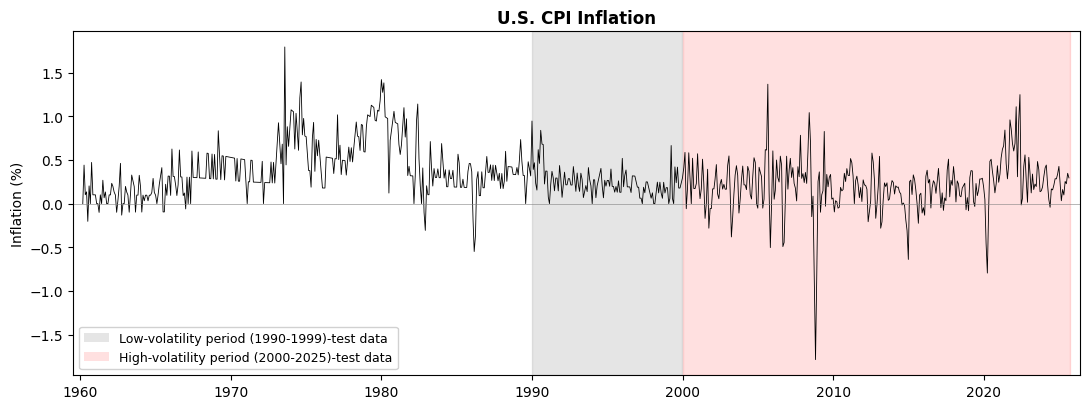

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# Period boundaries (Alt B split)
OOS_START   = "1990-01-01"
LOW_START,  LOW_END  = "1990-01-01", "1999-12-31"   # low-volatility test
HIGH_START, HIGH_END = "2000-01-01", "2025-09-30"   # high-volatility test

infl_pct = df_transformed["inflation"] * 100          # monthly inflation in %

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(infl_pct.index, infl_pct.values, color="black", lw=0.6)
ax.axhline(0, color="grey", lw=0.4)

# Shading: gray = low volatility, red = high volatility
ax.axvspan(pd.Timestamp(LOW_START),  pd.Timestamp(LOW_END),  color="grey", alpha=0.20)
ax.axvspan(pd.Timestamp(HIGH_START), pd.Timestamp(HIGH_END), color="red",  alpha=0.12)

# Legend (top-left)
legend_handles = [
    Patch(facecolor="grey", alpha=0.20, label="Low-volatility period (1990-1999)-test data"),
    Patch(facecolor="red",  alpha=0.12, label="High-volatility period (2000-2025)-test data"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9, framealpha=0.9)

ax.set_ylabel("Inflation (%)")
ax.set_title("U.S. CPI Inflation", loc="center", fontweight="bold")
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

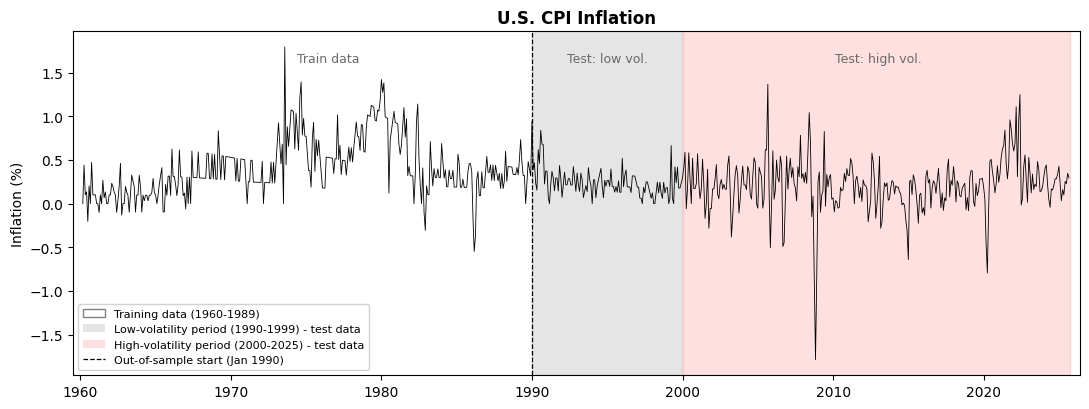

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Period boundaries (Alt B split)
OOS_START   = "1990-01-01"
LOW_START,  LOW_END  = "1990-01-01", "1999-12-31"   # low-volatility test
HIGH_START, HIGH_END = "2000-01-01", "2025-09-30"   # high-volatility test

infl_pct = df_transformed["inflation"] * 100          # monthly inflation in %

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(infl_pct.index, infl_pct.values, color="black", lw=0.6)

# Shading: white = train, gray = low-vol test, red = high-vol test
ax.axvspan(pd.Timestamp(LOW_START),  pd.Timestamp(LOW_END),  color="grey", alpha=0.20)
ax.axvspan(pd.Timestamp(HIGH_START), pd.Timestamp(HIGH_END), color="red",  alpha=0.12)

# Dashed line marking the start of the out-of-sample evaluation
ax.axvline(pd.Timestamp(OOS_START), color="black", lw=0.9, ls="--")

# Small period labels placed directly on the plot (top of each region)
y_top = infl_pct.max() * 0.97
ax.text(pd.Timestamp("1974-06-01"), y_top, "Train data",
        ha="left", va="top", fontsize=9, color="dimgrey")
ax.text(pd.Timestamp("1995-01-01"), y_top, "Test: low vol.",
        ha="center", va="top", fontsize=9, color="dimgrey")
ax.text(pd.Timestamp("2013-01-01"), y_top, "Test: high vol.",
        ha="center", va="top", fontsize=9, color="dimgrey")

# Legend (train + both test periods + OOS line)
legend_handles = [
    Patch(facecolor="white", edgecolor="grey", label="Training data (1960-1989)"),
    Patch(facecolor="grey",  alpha=0.20, label="Low-volatility period (1990-1999) - test data"),
    Patch(facecolor="red",   alpha=0.12, label="High-volatility period (2000-2025) - test data"),
    Line2D([0], [0], color="black", lw=0.9, ls="--", label="Out-of-sample start (Jan 1990)"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=8, framealpha=0.9)

ax.set_ylabel("Inflation (%)")
ax.set_title("U.S. CPI Inflation", loc="center", fontweight="bold")
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

In [ ]:
infl = df_transformed["inflation"] * 100   # keep same % units as the plot

def stat_row(s):
    return [s.mean(), s.std(), s.max(), s.min()]

low  = infl.loc[LOW_START:LOW_END]
high = infl.loc[HIGH_START:HIGH_END]

table3 = pd.DataFrame(
    [stat_row(low), stat_row(high)],
    index=["Low Volatility Period: 1990-1999",
           "High Volatility Period: 2000-2025"],
    columns=["Mean", "Sd", "Max", "Min"]
).round(3)

print("Table 3. Descriptive statistics of forecasted variable (CPI)")
print(table3.to_string())

Table 3. Descriptive statistics of forecasted variable (CPI)
                                    Mean     Sd    Max    Min
Low Volatility Period: 1990-1999   0.242  0.163  0.946  0.000
High Volatility Period: 2000-2025  0.211  0.302  1.367 -1.786


In [ ]:
# ============================================================
# FOUNDATION — shared helper functions and config
# ============================================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ---- Global config (used by every model) ----
OOS_START = "1990-01-01"
horizons  = [1, 3, 6, 9, 12]
pred_cols = [c for c in df_lags.columns if c not in ["inflation", "target", "date"]]

# ---- Rolling window size (computed ONCE per horizon) ----
def compute_window_size(df_h, h, t):
    """Fixed rolling window size, computed ONCE per horizon."""
    n_insample = len(df_h[df_h.index < t])   # months available up to t
    Rh = n_insample - h                       # window size
    return Rh


# ---- Target builder (future inflation at t+h) ----
def get_target(df, h):
    """Create target = inflation h steps ahead."""
    df_h = df.copy()
    df_h["target"] = df_h["inflation"].shift(-h)   # shift(-h) moves future values up
    df_h = df_h.dropna(subset=["target"])
    return df_h


# ---- Standardization (fit on train only, apply to both) ----
def standardize_predictors(X_train, X_test):
    scaler = StandardScaler()
    X_train_stdized = scaler.fit_transform(X_train)
    X_test_stdized  = scaler.transform(X_test)
    return X_train_stdized, X_test_stdized


# ---- Inner-loop validation split (time-ordered 80/20) ----
def split_train_val(X, y, val_frac=0.2):
    """
    Split a training window into training-subset + validation.
    Validation = LAST 20% in time order (no shuffling -> no leakage).
    """
    n = len(X)
    cut = int(n * (1 - val_frac))
    X_sub, X_val = X[:cut], X[cut:]
    y_sub, y_val = y[:cut], y[cut:]
    return X_sub, X_val, y_sub, y_val


# ---- MAD (Medeiros et al. 2019) ----
def compute_mad(actuals, forecasts):
    """MAD = median(|e - median(e)|)."""
    errors = actuals - forecasts
    return np.median(np.abs(errors - np.median(errors)))


# ---- Metrics helper (one call instead of repeating 3 lines) ----
def compute_metrics(actuals, forecasts):
    """Return RMSE, MAE, MAD as a tuple."""
    actuals   = np.array(actuals)
    forecasts = np.array(forecasts)
    rmse = np.sqrt(np.mean((actuals - forecasts) ** 2))
    mae  = np.mean(np.abs(actuals - forecasts))
    mad  = compute_mad(actuals, forecasts)
    return rmse, mae, mad

In [ ]:
# ============================================================
# RANDOM WALK MODEL: forecast = current inflation
# π̂_{t+h|t} = πt  (same for all horizons)
# ============================================================
def run_rw(df_lags, horizons, oos_start):
    rw_results = {}
    for h in horizons:
        df_h = get_target(df_lags, h)
        oos_dates = df_h[df_h.index >= oos_start].index

        actuals = []
        forecasts = []
        for t in oos_dates:
            loc = df_h.index.get_loc(t)
            row = df_h.iloc[loc]
            actuals.append(row["target"])       # actual inflation at t+h
            forecasts.append(row["inflation"])  # forecast = current inflation at t

        actuals = np.array(actuals)
        forecasts = np.array(forecasts)
        rmse, mae, mad = compute_metrics(actuals, forecasts)

        rw_results[h] = {"actuals": actuals, "forecasts": forecasts,
                         "dates": oos_dates,
                         "RMSE": rmse, "MAE": mae, "MAD": mad,
                         "extra": {}}
        print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f}")
    return rw_results


rw_results = run_rw(df_lags, horizons, OOS_START)

h= 1 | n=428 | RMSE=0.002789 | MAE=0.001953 | MAD=0.001390
h= 3 | n=426 | RMSE=0.003681 | MAE=0.002542 | MAD=0.001739
h= 6 | n=423 | RMSE=0.003701 | MAE=0.002503 | MAD=0.001796
h= 9 | n=420 | RMSE=0.003717 | MAE=0.002494 | MAD=0.001750
h=12 | n=417 | RMSE=0.003927 | MAE=0.002725 | MAD=0.002020


In [ ]:
# ============================================================
# AR(p) MODEL: uses only inflation lags, lag order p chosen by BIC
# π̂_{t+h|t} = φ0 + φ1·πt + ... + φp·πt-p+1
# ============================================================
from statsmodels.regression.linear_model import OLS
from collections import Counter

def run_ar(df_lags, horizons, oos_start, max_p=4):
    ar_results = {}
    ar_cols = sorted([c for c in df_lags.columns if c.startswith("inflation_lag")])[:max_p]

    for h in horizons:
        df_h = get_target(df_lags, h)
        Rh = compute_window_size(df_h, h, oos_start)
        oos_dates = df_h[df_h.index >= oos_start].index

        actuals = []
        forecasts = []
        chosen_p = []

        for t in oos_dates:
            loc = df_h.index.get_loc(t)
            train = df_h.iloc[loc - Rh : loc]
            test  = df_h.iloc[loc]

            y_train = train["target"].values

            best_bic = np.inf
            best_forecast = None
            best_p = 1

            for p in range(1, max_p + 1):
                cols = ar_cols[:p]
                X_train = np.column_stack([np.ones(len(train)), train[cols].values])
                X_test  = np.hstack([1.0, test[cols].values])

                model = OLS(y_train, X_train).fit()
                if model.bic < best_bic:
                    best_bic = model.bic
                    best_forecast = X_test @ model.params
                    best_p = p

            actuals.append(test["target"])
            forecasts.append(best_forecast)
            chosen_p.append(best_p)

        actuals = np.array(actuals)
        forecasts = np.array(forecasts)
        rmse, mae, mad = compute_metrics(actuals, forecasts)

        top_p = Counter(chosen_p).most_common(1)[0]

        ar_results[h] = {"actuals": actuals, "forecasts": forecasts,
                         "dates": oos_dates,
                         "RMSE": rmse, "MAE": mae, "MAD": mad,
                         "extra": {"chosen_p": chosen_p, "top_p": top_p}}
        print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f} | "
              f"Most chosen p={top_p[0]} ({top_p[1]}/{len(chosen_p)} windows)")
    return ar_results


ar_results = run_ar(df_lags, horizons, OOS_START, max_p=4)

h= 1 | n=428 | RMSE=0.002931 | MAE=0.001970 | MAD=0.001313 | Most chosen p=4 (218/428 windows)
h= 3 | n=426 | RMSE=0.002864 | MAE=0.001901 | MAD=0.001284 | Most chosen p=4 (231/426 windows)
h= 6 | n=423 | RMSE=0.002823 | MAE=0.001903 | MAD=0.001291 | Most chosen p=4 (236/423 windows)
h= 9 | n=420 | RMSE=0.002797 | MAE=0.001933 | MAD=0.001372 | Most chosen p=2 (230/420 windows)
h=12 | n=417 | RMSE=0.002894 | MAE=0.002018 | MAD=0.001336 | Most chosen p=3 (203/417 windows)


In [ ]:
# ============================================================
# AORW MODEL: forecast = average of last 12 months of inflation
# π̂_{t+h|t} = (1/12)(πt + πt-1 + ... + πt-11)
# ============================================================
def run_aorw(df_lags, horizons, oos_start):
    aorw_results = {}
    for h in horizons:
        # Build its own 12 inflation lags (df_lags only has 4)
        df_aorw = df_lags[["inflation"]].copy()
        for lag in range(1, 12):
            df_aorw[f"inf_lag{lag}"] = df_aorw["inflation"].shift(lag)
        df_aorw = df_aorw.dropna()

        df_aorw["target"] = df_aorw["inflation"].shift(-h)
        df_aorw = df_aorw.dropna()

        oos_dates = df_aorw[df_aorw.index >= oos_start].index

        actuals = []
        forecasts = []
        for t in oos_dates:
            loc = df_aorw.index.get_loc(t)
            row = df_aorw.iloc[loc]
            twelve_months = [row["inflation"]] + [row[f"inf_lag{i}"] for i in range(1, 12)]
            forecast = np.mean(twelve_months)
            actuals.append(row["target"])
            forecasts.append(forecast)

        actuals = np.array(actuals)
        forecasts = np.array(forecasts)
        rmse, mae, mad = compute_metrics(actuals, forecasts)

        aorw_results[h] = {"actuals": actuals, "forecasts": forecasts,
                           "dates": oos_dates,
                           "RMSE": rmse, "MAE": mae, "MAD": mad,
                           "extra": {}}
        print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f}")
    return aorw_results


aorw_results = run_aorw(df_lags, horizons, OOS_START)

h= 1 | n=428 | RMSE=0.002676 | MAE=0.001833 | MAD=0.001295
h= 3 | n=426 | RMSE=0.002824 | MAE=0.001918 | MAD=0.001350
h= 6 | n=423 | RMSE=0.002801 | MAE=0.001913 | MAD=0.001323
h= 9 | n=420 | RMSE=0.002837 | MAE=0.001929 | MAD=0.001299
h=12 | n=417 | RMSE=0.002935 | MAE=0.001997 | MAD=0.001319


In [ ]:
from scipy.optimize import minimize

def gas_filter(y, omega, A, B, sigma2):
    """
    GAS(1,1) time-varying mean with INVERSE-INFORMATION scaling.
    With S_t = sigma2, the scaled score is just the forecast error (y_t - f_t).
    """
    T = len(y)
    f = np.zeros(T)
    loglik = 0.0

    f[0] = np.mean(y)

    for t in range(T):
        loglik += -0.5*np.log(2*np.pi*sigma2) - (y[t] - f[t])**2 / (2*sigma2)

        # scaled score = forecast error (stable, no division by tiny sigma2)
        score = y[t] - f[t]

        if t < T - 1:
            f[t+1] = omega + A*score + B*f[t]

    return f, loglik


def gas_negloglik(params, y):
    omega, A, B, log_sigma2 = params
    sigma2 = np.exp(log_sigma2)
    # guard against bad parameter regions
    if not np.isfinite(sigma2) or sigma2 <= 0:
        return 1e10
    _, loglik = gas_filter(y, omega, A, B, sigma2)
    if not np.isfinite(loglik):
        return 1e10
    return -loglik


def gas_fit(y):
    start = [np.mean(y), 0.05, 0.9, np.log(np.var(y))]
    result = minimize(gas_negloglik, start, args=(y,),
                      method="Nelder-Mead",
                      options={"maxiter": 2000, "xatol": 1e-8, "fatol": 1e-8})
    omega, A, B, log_sigma2 = result.x
    return omega, A, B, np.exp(log_sigma2)

In [ ]:
# ============================================================
# GAS(1,1) — rolling window forecast
# (gas_filter, gas_negloglik, gas_fit stay as defined above)
# ============================================================
def run_gas(df_lags, horizons, oos_start):
    gas_results = {}
    for h in horizons:
        df_h = get_target(df_lags, h)
        Rh = compute_window_size(df_h, h, oos_start)
        oos_dates = df_h[df_h.index >= oos_start].index

        actuals = []
        forecasts = []
        for t in oos_dates:
            loc = df_h.index.get_loc(t)
            train = df_h.iloc[loc - Rh: loc]

            y_train = train["inflation"].values
            y_actual = df_h.iloc[loc]["target"]

            omega, A, B, sigma2 = gas_fit(y_train)

            f, _ = gas_filter(y_train, omega, A, B, sigma2)
            f_origin = omega + A * (y_train[-1] - f[-1]) + B * f[-1]
            f_next = f_origin
            for _ in range(h):
                f_next = omega + B*f_next
            forecast = f_next

            actuals.append(y_actual)
            forecasts.append(forecast)

        actuals = np.array(actuals)
        forecasts = np.array(forecasts)
        rmse, mae, mad = compute_metrics(actuals, forecasts)

        gas_results[h] = {"actuals": actuals, "forecasts": forecasts,
                          "dates": oos_dates,
                          "RMSE": rmse, "MAE": mae, "MAD": mad,
                          "extra": {}}
        print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f}")
    return gas_results


gas_results = run_gas(df_lags, horizons, OOS_START)

h= 1 | n=428 | RMSE=0.002849 | MAE=0.001926 | MAD=0.001341
h= 3 | n=426 | RMSE=0.002808 | MAE=0.001857 | MAD=0.001205
h= 6 | n=423 | RMSE=0.002806 | MAE=0.001908 | MAD=0.001288
h= 9 | n=420 | RMSE=0.002795 | MAE=0.001902 | MAD=0.001287
h=12 | n=417 | RMSE=0.002920 | MAE=0.002009 | MAD=0.001333


In [ ]:
import numpy as np
print("corr(RW, AORW) at h=1:",
      np.corrcoef(ar_results[1]["forecasts"], gas_results[1]["forecasts"])[0, 1])
print("identical?",
      np.allclose(ar_results[1]["forecasts"], gas_results[1]["forecasts"]))

corr(RW, AORW) at h=1: 0.9011172206444154
identical? False


In [ ]:
# ============================================================
# Ridge with hyperparameter tuning (Huang's two-loop structure)
# ============================================================
from sklearn.linear_model import Ridge
from collections import Counter

def run_ridge(df_lags, horizons, oos_start, pred_cols,
              alpha_grid=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]):
    ridge_results = {}

    for h in horizons:
        df_h = get_target(df_lags, h)
        Rh = compute_window_size(df_h, h, oos_start)
        oos_dates = df_h[df_h.index >= oos_start].index

        actuals = []
        forecasts = []
        chosen_alphas = []

        for t in oos_dates:
            loc = df_h.index.get_loc(t)
            train = df_h.iloc[loc - Rh: loc]
            test = df_h.iloc[loc]

            X_train = train[pred_cols].values
            y_train = train["target"].values
            X_test = test[pred_cols].values.reshape(1, -1)
            y_actual = test["target"]

            # ---------- INNER LOOP: tune alpha on validation RMSE ----------
            X_sub, X_val, y_sub, y_val = split_train_val(X_train, y_train, val_frac=0.2)
            scaler_inner = StandardScaler()
            X_sub_s = scaler_inner.fit_transform(X_sub)
            X_val_s = scaler_inner.transform(X_val)

            best_alpha = None
            best_rmse = np.inf
            for i in alpha_grid:
                model = Ridge(alpha=i).fit(X_sub_s, y_sub)
                val_pred = model.predict(X_val_s)
                val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
                if val_rmse < best_rmse:
                    best_rmse = val_rmse
                    best_alpha = i

            # ---------- OUTER LOOP: refit on FULL window with best alpha ----------
            scaler_outer = StandardScaler()
            X_train_s = scaler_outer.fit_transform(X_train)
            X_test_s = scaler_outer.transform(X_test)
            model = Ridge(alpha=best_alpha).fit(X_train_s, y_train)
            forecast = model.predict(X_test_s)[0]

            actuals.append(y_actual)
            forecasts.append(forecast)
            chosen_alphas.append(best_alpha)

        actuals = np.array(actuals)
        forecasts = np.array(forecasts)
        rmse, mae, mad = compute_metrics(actuals, forecasts)

        top_alpha = Counter(chosen_alphas).most_common(1)[0]

        ridge_results[h] = {"actuals": actuals, "forecasts": forecasts,
                            "dates": oos_dates,
                            "RMSE": rmse, "MAE": mae, "MAD": mad,
                            "extra": {"chosen_alphas": chosen_alphas, "top_alpha": top_alpha}}
        print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f} | "
              f"Most chosen alpha={top_alpha[0]} ({top_alpha[1]}/{len(chosen_alphas)} windows)")
    return ridge_results


ridge_results = run_ridge(df_lags, horizons, OOS_START, pred_cols)

h= 1 | n=428 | RMSE=0.002787 | MAE=0.001893 | MAD=0.001374 | Most chosen alpha=1000.0 (242/428 windows)
h= 3 | n=426 | RMSE=0.002887 | MAE=0.001919 | MAD=0.001314 | Most chosen alpha=1000.0 (282/426 windows)
h= 6 | n=423 | RMSE=0.002789 | MAE=0.001920 | MAD=0.001373 | Most chosen alpha=1000.0 (248/423 windows)
h= 9 | n=420 | RMSE=0.002801 | MAE=0.001920 | MAD=0.001419 | Most chosen alpha=1000.0 (195/420 windows)
h=12 | n=417 | RMSE=0.002846 | MAE=0.001979 | MAD=0.001457 | Most chosen alpha=1000.0 (259/417 windows)


In [ ]:
# ============================================================
# LASSO with hyperparameter tuning (Huang's two-loop structure)
# ============================================================
from sklearn.linear_model import Lasso
from collections import Counter

def run_lasso(df_lags, horizons, oos_start, pred_cols,
              alpha_grid=np.logspace(-5, 0, 12)):
    lasso_results = {}

    for h in horizons:
        df_h = get_target(df_lags, h)
        Rh = compute_window_size(df_h, h, oos_start)
        oos_dates = df_h[df_h.index >= oos_start].index

        actuals = []
        forecasts = []
        chosen_alphas = []

        for t in oos_dates:
            loc = df_h.index.get_loc(t)
            train = df_h.iloc[loc - Rh: loc]
            test = df_h.iloc[loc]

            X_train = train[pred_cols].values
            y_train = train["target"].values
            X_test = test[pred_cols].values.reshape(1, -1)
            y_actual = test["target"]

            # ---------- INNER LOOP: tune alpha on validation RMSE ----------
            X_sub, X_val, y_sub, y_val = split_train_val(X_train, y_train, val_frac=0.2)
            scaler_inner = StandardScaler()
            X_sub_s = scaler_inner.fit_transform(X_sub)
            X_val_s = scaler_inner.transform(X_val)

            best_alpha = None
            best_rmse = np.inf
            for i in alpha_grid:
                model = Lasso(alpha=i, max_iter=30000).fit(X_sub_s, y_sub)
                val_pred = model.predict(X_val_s)
                val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
                if val_rmse < best_rmse:
                    best_rmse = val_rmse
                    best_alpha = i

            # ---------- OUTER LOOP: refit on FULL window with best alpha ----------
            scaler_outer = StandardScaler()
            X_train_s = scaler_outer.fit_transform(X_train)
            X_test_s = scaler_outer.transform(X_test)
            model = Lasso(alpha=best_alpha, max_iter=30000).fit(X_train_s, y_train)
            forecast = model.predict(X_test_s)[0]

            actuals.append(y_actual)
            forecasts.append(forecast)
            chosen_alphas.append(best_alpha)

        actuals = np.array(actuals)
        forecasts = np.array(forecasts)
        rmse, mae, mad = compute_metrics(actuals, forecasts)

        top_alpha = Counter(chosen_alphas).most_common(1)[0]

        lasso_results[h] = {"actuals": actuals, "forecasts": forecasts,
                            "dates": oos_dates,
                            "RMSE": rmse, "MAE": mae, "MAD": mad,
                            "extra": {"chosen_alphas": chosen_alphas, "top_alpha": top_alpha}}
        print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f} | "
              f"Most chosen alpha={top_alpha[0]} ({top_alpha[1]}/{len(chosen_alphas)} windows)")
    return lasso_results


lasso_results = run_lasso(df_lags, horizons, OOS_START, pred_cols)

h= 1 | n=428 | RMSE=0.002870 | MAE=0.001930 | MAD=0.001336 | Most chosen alpha=0.0002310129700083158 (283/428 windows)
h= 3 | n=426 | RMSE=0.002955 | MAE=0.001956 | MAD=0.001365 | Most chosen alpha=0.0002310129700083158 (224/426 windows)
h= 6 | n=423 | RMSE=0.002798 | MAE=0.001902 | MAD=0.001316 | Most chosen alpha=0.0002310129700083158 (201/423 windows)
h= 9 | n=420 | RMSE=0.002753 | MAE=0.001883 | MAD=0.001349 | Most chosen alpha=0.0002310129700083158 (172/420 windows)
h=12 | n=417 | RMSE=0.002871 | MAE=0.001942 | MAD=0.001308 | Most chosen alpha=0.0002310129700083158 (152/417 windows)


In [ ]:
from sklearn.linear_model import Lasso

def adalasso_fit(X, y, alpha, first_step_alpha=None, max_iter=5000):
    """
    Adaptive LASSO (Zou 2006), first step = LASSO.
    Weight formula (Huang / Medeiros): w_i = 1 / (|beta_init_i| + 1/sqrt(T))
    """
    T = len(y)

    # --- Step 1: initial estimate via LASSO ---
    if first_step_alpha is None:
        first_step_alpha = alpha          # simple choice: reuse same alpha
    lasso_init = Lasso(alpha=first_step_alpha, max_iter=max_iter).fit(X, y)
    beta_init = lasso_init.coef_

    # --- Adaptive weights (Huang/Medeiros formula, avoids zero denominator) ---
    weights = 1.0 / (np.abs(beta_init) + 1.0 / np.sqrt(T))

    # --- Step 2: rescale features, run ordinary LASSO ---
    X_weighted = X / weights
    model = Lasso(alpha=alpha, max_iter=max_iter).fit(X_weighted, y)

    # --- Rescale coefficients back ---
    beta_adalasso = model.coef_ / weights
    intercept = model.intercept_

    return beta_adalasso, intercept

In [ ]:
# ============================================================
# adaLASSO with hyperparameter tuning (Huang's two-loop structure)
# ============================================================
from collections import Counter

def run_adalasso(df_lags, horizons, oos_start, pred_cols,
                 alpha_grid=np.logspace(-5, 0, 12)):
    adalasso_results = {}

    for h in horizons:
        df_h = get_target(df_lags, h)
        Rh = compute_window_size(df_h, h, oos_start)
        oos_dates = df_h[df_h.index >= oos_start].index

        actuals = []
        forecasts = []
        chosen_alphas = []

        for t in oos_dates:
            loc = df_h.index.get_loc(t)
            train = df_h.iloc[loc - Rh: loc]
            test = df_h.iloc[loc]

            X_train = train[pred_cols].values
            y_train = train["target"].values
            X_test = test[pred_cols].values.reshape(1, -1)
            y_actual = test["target"]

            # ---------- INNER LOOP: tune alpha on validation RMSE ----------
            X_sub, X_val, y_sub, y_val = split_train_val(X_train, y_train, val_frac=0.2)
            scaler_inner = StandardScaler()
            X_sub_s = scaler_inner.fit_transform(X_sub)
            X_val_s = scaler_inner.transform(X_val)

            best_alpha = None
            best_rmse = np.inf
            for a in alpha_grid:
                beta, intercept = adalasso_fit(X_sub_s, y_sub, alpha=a)
                val_pred = X_val_s @ beta + intercept
                val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
                if val_rmse < best_rmse:
                    best_rmse = val_rmse
                    best_alpha = a

            # ---------- OUTER LOOP: refit on FULL window with best alpha ----------
            scaler_outer = StandardScaler()
            X_train_s = scaler_outer.fit_transform(X_train)
            X_test_s = scaler_outer.transform(X_test)
            beta, intercept = adalasso_fit(X_train_s, y_train, alpha=best_alpha)
            forecast = (X_test_s @ beta + intercept)[0]

            actuals.append(y_actual)
            forecasts.append(forecast)
            chosen_alphas.append(best_alpha)

        actuals = np.array(actuals)
        forecasts = np.array(forecasts)
        rmse, mae, mad = compute_metrics(actuals, forecasts)

        top_alpha = Counter(chosen_alphas).most_common(1)[0]

        adalasso_results[h] = {"actuals": actuals, "forecasts": forecasts,
                               "dates": oos_dates,
                               "RMSE": rmse, "MAE": mae, "MAD": mad,
                               "extra": {"chosen_alphas": chosen_alphas, "top_alpha": top_alpha}}
        print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f} | "
              f"alpha={top_alpha[0]:.5f} ({top_alpha[1]}/{len(chosen_alphas)})")
    return adalasso_results


adalasso_results = run_adalasso(df_lags, horizons, OOS_START, pred_cols)

h= 1 | n=428 | RMSE=0.002876 | MAE=0.001946 | MAD=0.001353 | alpha=0.00001 (198/428)
h= 3 | n=426 | RMSE=0.002847 | MAE=0.001926 | MAD=0.001379 | alpha=0.00001 (220/426)
h= 6 | n=423 | RMSE=0.002756 | MAE=0.001902 | MAD=0.001322 | alpha=0.00001 (191/423)
h= 9 | n=420 | RMSE=0.002792 | MAE=0.001900 | MAD=0.001257 | alpha=0.00003 (168/420)
h=12 | n=417 | RMSE=0.002776 | MAE=0.001872 | MAD=0.001297 | alpha=0.00001 (257/417)


In [ ]:
# ============================================================
# Elastic Net with hyperparameter tuning (Huang's two-loop structure)
# l1_ratio fixed at 0.5 (Medeiros et al.) — only alpha is tuned
# ============================================================
from sklearn.linear_model import ElasticNet
from collections import Counter

def run_elasticnet(df_lags, horizons, oos_start, pred_cols,
                   alpha_grid=np.logspace(-5, 0, 12),
                   l1_ratio=0.5):
    elasticnet_results = {}

    for h in horizons:
        df_h = get_target(df_lags, h)
        Rh = compute_window_size(df_h, h, oos_start)
        oos_dates = df_h[df_h.index >= oos_start].index

        actuals = []
        forecasts = []
        chosen_alphas = []

        for t in oos_dates:
            loc = df_h.index.get_loc(t)
            train = df_h.iloc[loc - Rh: loc]
            test = df_h.iloc[loc]

            X_train = train[pred_cols].values
            y_train = train["target"].values
            X_test = test[pred_cols].values.reshape(1, -1)
            y_actual = test["target"]

            # ---------- INNER LOOP: tune alpha on validation RMSE (l1 fixed) ----------
            X_sub, X_val, y_sub, y_val = split_train_val(X_train, y_train, val_frac=0.2)
            scaler_inner = StandardScaler()
            X_sub_s = scaler_inner.fit_transform(X_sub)
            X_val_s = scaler_inner.transform(X_val)

            best_alpha = None
            best_rmse = np.inf
            for i in alpha_grid:
                model = ElasticNet(alpha=i, l1_ratio=l1_ratio, max_iter=30000).fit(X_sub_s, y_sub)
                val_pred = model.predict(X_val_s)
                val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
                if val_rmse < best_rmse:
                    best_rmse = val_rmse
                    best_alpha = i

            # ---------- OUTER LOOP: refit on FULL window with best alpha ----------
            scaler_outer = StandardScaler()
            X_train_s = scaler_outer.fit_transform(X_train)
            X_test_s = scaler_outer.transform(X_test)
            model = ElasticNet(alpha=best_alpha, l1_ratio=l1_ratio, max_iter=30000).fit(X_train_s, y_train)
            forecast = model.predict(X_test_s)[0]

            actuals.append(y_actual)
            forecasts.append(forecast)
            chosen_alphas.append(best_alpha)

        actuals = np.array(actuals)
        forecasts = np.array(forecasts)
        rmse, mae, mad = compute_metrics(actuals, forecasts)

        top_alpha = Counter(chosen_alphas).most_common(1)[0]

        elasticnet_results[h] = {"actuals": actuals, "forecasts": forecasts,
                                 "dates": oos_dates,
                                 "RMSE": rmse, "MAE": mae, "MAD": mad,
                                 "extra": {"chosen_alphas": chosen_alphas, "top_alpha": top_alpha,
                                           "l1_ratio": l1_ratio}}
        print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f} | "
              f"alpha={top_alpha[0]:.5f} ({top_alpha[1]}/{len(chosen_alphas)}) | l1={l1_ratio}")
    return elasticnet_results


elasticnet_results = run_elasticnet(df_lags, horizons, OOS_START, pred_cols)

h= 1 | n=428 | RMSE=0.002923 | MAE=0.001964 | MAD=0.001289 | alpha=0.00066 (296/428) | l1=0.5
h= 3 | n=426 | RMSE=0.002873 | MAE=0.001929 | MAD=0.001350 | alpha=0.00066 (258/426) | l1=0.5
h= 6 | n=423 | RMSE=0.002858 | MAE=0.001929 | MAD=0.001339 | alpha=0.00187 (163/423) | l1=0.5
h= 9 | n=420 | RMSE=0.002805 | MAE=0.001902 | MAD=0.001311 | alpha=0.00066 (151/420) | l1=0.5
h=12 | n=417 | RMSE=0.002802 | MAE=0.001898 | MAD=0.001311 | alpha=0.00023 (197/417) | l1=0.5


In [ ]:
# # ============================================================
# # RANDOM FOREST with hyperparameter tuning (Huang's two-loop)
# # ============================================================
# from sklearn.ensemble import RandomForestRegressor
# from collections import Counter

# def run_rf(df_lags, horizons, oos_start, pred_cols,
#            max_features_grid=[0.1, 0.2, 1/3, 0.5]):
#     rf_results = {}

#     for h in horizons:
#         df_h = get_target(df_lags, h)
#         Rh = compute_window_size(df_h, h, oos_start)
#         oos_dates = df_h[df_h.index >= oos_start].index

#         actuals = []
#         forecasts = []
#         chosen_mf = []

#         for t in oos_dates:
#             loc = df_h.index.get_loc(t)
#             train = df_h.iloc[loc - Rh: loc]
#             test = df_h.iloc[loc]

#             X_train = train[pred_cols].values
#             y_train = train["target"].values
#             X_test = test[pred_cols].values.reshape(1, -1)
#             y_actual = test["target"]

#             # ---------- INNER LOOP: tune max_features (no scaling — trees) ----------
#             X_sub, X_val, y_sub, y_val = split_train_val(X_train, y_train, val_frac=0.2)

#             best_mf = None
#             best_rmse = np.inf
#             for mf in max_features_grid:
#                 model = RandomForestRegressor(
#                     n_estimators=500,
#                     max_features=mf,
#                     min_samples_leaf=5,
#                     random_state=42,
#                     n_jobs=-1
#                 ).fit(X_sub, y_sub)
#                 val_pred = model.predict(X_val)
#                 val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
#                 if val_rmse < best_rmse:
#                     best_rmse = val_rmse
#                     best_mf = mf

#             # ---------- OUTER LOOP: refit on FULL window with best max_features ----------
#             model = RandomForestRegressor(
#                 n_estimators=500,
#                 max_features=best_mf,
#                 min_samples_leaf=5,
#                 random_state=42,
#                 n_jobs=-1
#             ).fit(X_train, y_train)
#             forecast = model.predict(X_test)[0]

#             actuals.append(y_actual)
#             forecasts.append(forecast)
#             chosen_mf.append(best_mf)

#         actuals = np.array(actuals)
#         forecasts = np.array(forecasts)
#         rmse, mae, mad = compute_metrics(actuals, forecasts)

#         top_mf = Counter(chosen_mf).most_common(1)[0]

#         rf_results[h] = {"actuals": actuals, "forecasts": forecasts,
#                          "dates": oos_dates,
#                          "RMSE": rmse, "MAE": mae, "MAD": mad,
#                          "extra": {"chosen_mf": chosen_mf, "top_mf": top_mf}}
#         print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f} | "
#               f"max_features={top_mf[0]:.3f} ({top_mf[1]}/{len(chosen_mf)})")
#     return rf_results


# rf_results = run_rf(df_lags, horizons, OOS_START, pred_cols)

In [ ]:
# ============================================================
# RANDOM FOREST with hyperparameter tuning (Huang's two-loop) — PARALLEL
# ============================================================
from sklearn.ensemble import RandomForestRegressor
from joblib import Parallel, delayed
from collections import Counter

def run_rf(df_lags, horizons, oos_start, pred_cols,
           max_features_grid=[0.1, 0.2, 0.3, 0.5]):
    rf_results = {}

    for h in horizons:
        df_h = get_target(df_lags, h)
        Rh = compute_window_size(df_h, h, oos_start)
        oos_dates = df_h[df_h.index >= oos_start].index

        # ---- work for ONE window ----
        def run_one_window(t):
            loc = df_h.index.get_loc(t)
            train = df_h.iloc[loc - Rh: loc]
            test = df_h.iloc[loc]

            X_train = train[pred_cols].values
            y_train = train["target"].values
            X_test = test[pred_cols].values.reshape(1, -1)
            y_actual = test["target"]

            # INNER LOOP: tune max_features (no scaling — trees)
            X_sub, X_val, y_sub, y_val = split_train_val(X_train, y_train, val_frac=0.2)
            best_mf, best_rmse = None, np.inf
            for mf in max_features_grid:
                m = RandomForestRegressor(n_estimators=500, max_features=mf,
                                          min_samples_leaf=5, random_state=42,
                                          n_jobs=1).fit(X_sub, y_sub)
                val_pred = m.predict(X_val)
                val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
                if val_rmse < best_rmse:
                    best_rmse = val_rmse
                    best_mf = mf

            # OUTER LOOP: refit on FULL window with best max_features
            model = RandomForestRegressor(n_estimators=500, max_features=best_mf,
                                          min_samples_leaf=5, random_state=42,
                                          n_jobs=1).fit(X_train, y_train)
            forecast = model.predict(X_test)[0]

            return y_actual, forecast, best_mf

        # ---- run all windows in parallel ----
        out = Parallel(n_jobs=-1)(delayed(run_one_window)(t) for t in oos_dates)

        actuals   = np.array([o[0] for o in out])
        forecasts = np.array([o[1] for o in out])
        chosen_mf = [o[2] for o in out]

        rmse, mae, mad = compute_metrics(actuals, forecasts)
        top_mf = Counter(chosen_mf).most_common(1)[0]

        rf_results[h] = {"actuals": actuals, "forecasts": forecasts,
                         "dates": oos_dates,
                         "RMSE": rmse, "MAE": mae, "MAD": mad,
                         "extra": {"chosen_mf": chosen_mf, "top_mf": top_mf}}
        print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f} | "
              f"max_features={top_mf[0]:.3f} ({top_mf[1]}/{len(chosen_mf)})")
    return rf_results


rf_results = run_rf(df_lags, horizons, OOS_START, pred_cols)

h= 1 | n=428 | RMSE=0.002730 | MAE=0.001862 | MAD=0.001316 | max_features=0.500 (156/428)
h= 3 | n=426 | RMSE=0.002676 | MAE=0.001833 | MAD=0.001262 | max_features=0.100 (157/426)
h= 6 | n=423 | RMSE=0.002643 | MAE=0.001806 | MAD=0.001255 | max_features=0.500 (164/423)
h= 9 | n=420 | RMSE=0.002630 | MAE=0.001776 | MAD=0.001230 | max_features=0.500 (170/420)
h=12 | n=417 | RMSE=0.002688 | MAE=0.001817 | MAD=0.001286 | max_features=0.100 (196/417)


In [ ]:
# # ============================================================
# # XGBOOST — Option B: trimmed grid (max_depth × eta), n_estimators fixed
# # ============================================================
# from xgboost import XGBRegressor
# from collections import Counter

# def run_xgb(df_lags, horizons, oos_start, pred_cols,
#             max_depth_grid=[2, 4, 6],
#             eta_grid=[0.1, 0.2, 0.3],
#             n_estimators=500):
#     xgb_results = {}

#     for h in horizons:
#         df_h = get_target(df_lags, h)
#         Rh = compute_window_size(df_h, h, oos_start)
#         oos_dates = df_h[df_h.index >= oos_start].index

#         actuals = []
#         forecasts = []
#         chosen_params = []

#         for t in oos_dates:
#             loc = df_h.index.get_loc(t)
#             train = df_h.iloc[loc - Rh: loc]
#             test = df_h.iloc[loc]

#             X_train = train[pred_cols].values
#             y_train = train["target"].values
#             X_test = test[pred_cols].values.reshape(1, -1)
#             y_actual = test["target"]

#             # ---------- INNER LOOP: tune max_depth, eta ----------
#             X_sub, X_val, y_sub, y_val = split_train_val(X_train, y_train, val_frac=0.2)

#             best_params = None
#             best_rmse = np.inf
#             for md in max_depth_grid:
#                 for eta in eta_grid:
#                     m = XGBRegressor(
#                         n_estimators=n_estimators,
#                         max_depth=md,
#                         learning_rate=eta,
#                         random_state=42,
#                         n_jobs=-1
#                     ).fit(X_sub, y_sub)
#                     val_pred = m.predict(X_val)
#                     val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
#                     if val_rmse < best_rmse:
#                         best_rmse = val_rmse
#                         best_params = (md, eta)

#             # ---------- OUTER LOOP: refit on FULL window with best params ----------
#             md, eta = best_params
#             model = XGBRegressor(
#                 n_estimators=n_estimators,
#                 max_depth=md,
#                 learning_rate=eta,
#                 random_state=42,
#                 n_jobs=-1
#             ).fit(X_train, y_train)
#             forecast = model.predict(X_test)[0]

#             actuals.append(y_actual)
#             forecasts.append(forecast)
#             chosen_params.append(best_params)

#         actuals = np.array(actuals)
#         forecasts = np.array(forecasts)
#         rmse, mae, mad = compute_metrics(actuals, forecasts)

#         top_params = Counter(chosen_params).most_common(1)[0]

#         xgb_results[h] = {"actuals": actuals, "forecasts": forecasts,
#                           "dates": oos_dates,
#                           "RMSE": rmse, "MAE": mae, "MAD": mad,
#                           "extra": {"chosen_params": chosen_params, "top_params": top_params}}
#         print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f} | "
#               f"best (depth,eta)={top_params[0]} ({top_params[1]}/{len(chosen_params)})")
#     return xgb_results


# xgb_results = run_xgb(df_lags, horizons, OOS_START, pred_cols)

In [ ]:
# ============================================================
# XGBOOST — Option B: trimmed grid (max_depth × eta) — PARALLEL
# ============================================================
from xgboost import XGBRegressor
from joblib import Parallel, delayed
from collections import Counter

def run_xgb(df_lags, horizons, oos_start, pred_cols,
            max_depth_grid=[2, 4, 6],
            eta_grid=[0.1, 0.2, 0.3],
            n_estimators=500):
    xgb_results = {}

    for h in horizons:
        df_h = get_target(df_lags, h)
        Rh = compute_window_size(df_h, h, oos_start)
        oos_dates = df_h[df_h.index >= oos_start].index

        # ---- work for ONE window ----
        def run_one_window(t):
            loc = df_h.index.get_loc(t)
            train = df_h.iloc[loc - Rh: loc]
            test = df_h.iloc[loc]

            X_train = train[pred_cols].values
            y_train = train["target"].values
            X_test = test[pred_cols].values.reshape(1, -1)
            y_actual = test["target"]

            # INNER LOOP: tune max_depth, eta
            X_sub, X_val, y_sub, y_val = split_train_val(X_train, y_train, val_frac=0.2)
            best_params, best_rmse = None, np.inf
            for md in max_depth_grid:
                for eta in eta_grid:
                    m = XGBRegressor(n_estimators=n_estimators, max_depth=md,
                                     learning_rate=eta,tree_method = "hist" ,random_state=42,
                                     n_jobs=1).fit(X_sub, y_sub)
                    val_pred = m.predict(X_val)
                    val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
                    if val_rmse < best_rmse:
                        best_rmse = val_rmse
                        best_params = (md, eta)

            # OUTER LOOP: refit on FULL window with best params
            md, eta = best_params
            model = XGBRegressor(n_estimators=n_estimators, max_depth=md,
                                 learning_rate=eta, tree_method="hist" ,random_state=42,
                                 n_jobs=1).fit(X_train, y_train)
            forecast = model.predict(X_test)[0]

            return y_actual, forecast, best_params

        # ---- run all windows in parallel ----
        out = Parallel(n_jobs=-1)(delayed(run_one_window)(t) for t in oos_dates)

        actuals       = np.array([o[0] for o in out])
        forecasts     = np.array([o[1] for o in out])
        chosen_params = [o[2] for o in out]

        rmse, mae, mad = compute_metrics(actuals, forecasts)
        top_params = Counter(chosen_params).most_common(1)[0]

        xgb_results[h] = {"actuals": actuals, "forecasts": forecasts,
                          "dates": oos_dates,
                          "RMSE": rmse, "MAE": mae, "MAD": mad,
                          "extra": {"chosen_params": chosen_params, "top_params": top_params}}
        print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f} | "
              f"best (depth,eta)={top_params[0]} ({top_params[1]}/{len(chosen_params)})")
    return xgb_results


xgb_results = run_xgb(df_lags, horizons, OOS_START, pred_cols)

h= 1 | n=428 | RMSE=0.002991 | MAE=0.002033 | MAD=0.001443 | best (depth,eta)=(6, 0.1) (78/428)


/home/dph207/.local/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


h= 3 | n=426 | RMSE=0.002900 | MAE=0.002021 | MAD=0.001476 | best (depth,eta)=(6, 0.1) (66/426)
h= 6 | n=423 | RMSE=0.002795 | MAE=0.001933 | MAD=0.001346 | best (depth,eta)=(2, 0.1) (72/423)
h= 9 | n=420 | RMSE=0.002696 | MAE=0.001828 | MAD=0.001278 | best (depth,eta)=(4, 0.1) (77/420)
h=12 | n=417 | RMSE=0.003086 | MAE=0.002104 | MAD=0.001456 | best (depth,eta)=(2, 0.1) (102/417)


In [ ]:
#Hybrid ML Models

In [ ]:
# ============================================================
# HYBRID: adaLASSO-XGBoost
# Stage 1: adaLASSO selects features (non-zero coefficients)
# Stage 2: XGBoost forecasts using ONLY the selected features
# ============================================================
from xgboost import XGBRegressor
from joblib import Parallel, delayed
from collections import Counter


def adalasso_select(X, y, alpha, min_keep=2):
    """
    Use adaLASSO to pick features. Returns indices of non-zero coefficients.
    Safety net: if fewer than min_keep selected, keep the top |coef| features.
    """
    beta, _ = adalasso_fit(X, y, alpha=alpha)
    selected = np.where(beta != 0)[0]
    if len(selected) < min_keep:
        selected = np.argsort(np.abs(beta))[::-1][:min_keep]   # top |coef|
    return selected


def run_adalasso_xgb(df_lags, horizons, oos_start, pred_cols,
                     sel_alpha_grid=np.logspace(-5, 0, 12),   # adaLASSO selection
                     max_depth_grid=[2, 4, 6],                 # XGBoost
                     eta_grid=[0.1, 0.2, 0.3],
                     n_estimators=500):
    results = {}

    for h in horizons:
        df_h = get_target(df_lags, h)
        Rh = compute_window_size(df_h, h, oos_start)
        oos_dates = df_h[df_h.index >= oos_start].index

        # ---- work for ONE window ----
        def run_one_window(t):
            loc = df_h.index.get_loc(t)
            train = df_h.iloc[loc - Rh: loc]
            test  = df_h.iloc[loc]

            X_train = train[pred_cols].values
            y_train = train["target"].values
            X_test  = test[pred_cols].values.reshape(1, -1)
            y_actual = test["target"]

            X_sub, X_val, y_sub, y_val = split_train_val(X_train, y_train, val_frac=0.2)

            # ===== STAGE 1: adaLASSO feature selection =====
            # adaLASSO needs scaling
            scaler_sel = StandardScaler()
            X_sub_s = scaler_sel.fit_transform(X_sub)
            X_val_s = scaler_sel.transform(X_val)

            # pick selection alpha by validation RMSE
            best_alpha, best_sel_rmse = None, np.inf
            for a in sel_alpha_grid:
                beta, intercept = adalasso_fit(X_sub_s, y_sub, alpha=a)
                val_pred = X_val_s @ beta + intercept
                val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
                if val_rmse < best_sel_rmse:
                    best_sel_rmse = val_rmse
                    best_alpha = a

            # selected feature indices from full window at best alpha
            scaler_full = StandardScaler()
            X_train_s = scaler_full.fit_transform(X_train)
            selected = adalasso_select(X_train_s, y_train, alpha=best_alpha)

            # ===== STAGE 2: XGBoost on selected features (NO scaling) =====
            X_sub_sel = X_sub[:, selected]
            X_val_sel = X_val[:, selected]

            best_params, best_xgb_rmse = None, np.inf
            for md in max_depth_grid:
                for eta in eta_grid:
                    m = XGBRegressor(n_estimators=n_estimators, max_depth=md,
                                     learning_rate=eta, tree_method="hist" ,random_state=42,
                                     n_jobs=1).fit(X_sub_sel, y_sub)   # n_jobs=1!
                    val_pred = m.predict(X_val_sel)
                    val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
                    if val_rmse < best_xgb_rmse:
                        best_xgb_rmse = val_rmse
                        best_params = (md, eta)

            # refit XGBoost on FULL window, selected features
            md, eta = best_params
            X_train_sel = X_train[:, selected]
            X_test_sel  = X_test[:, selected]
            model = XGBRegressor(n_estimators=n_estimators, max_depth=md,
                                 learning_rate=eta, tree_method="hist" ,random_state=42,
                                 n_jobs=1).fit(X_train_sel, y_train)
            forecast = model.predict(X_test_sel)[0]

            return y_actual, forecast, best_alpha, best_params, len(selected)

        # ---- run all windows in parallel ----
        out = Parallel(n_jobs=-1)(delayed(run_one_window)(t) for t in oos_dates)

        actuals       = np.array([o[0] for o in out])
        forecasts     = np.array([o[1] for o in out])
        chosen_alphas = [o[2] for o in out]
        chosen_params = [o[3] for o in out]
        n_selected    = [o[4] for o in out]

        rmse, mae, mad = compute_metrics(actuals, forecasts)
        top_alpha  = Counter(chosen_alphas).most_common(1)[0]
        top_params = Counter(chosen_params).most_common(1)[0]
        avg_selected = np.mean(n_selected)

        results[h] = {"actuals": actuals, "forecasts": forecasts,
                      "dates": oos_dates,
                      "RMSE": rmse, "MAE": mae, "MAD": mad,
                      "extra": {"chosen_alphas": chosen_alphas, "top_alpha": top_alpha,
                                "chosen_params": chosen_params, "top_params": top_params,
                                "avg_selected": avg_selected}}
        print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f} | "
              f"sel_alpha={top_alpha[0]:.5f} | xgb(depth,eta)={top_params[0]} | "
              f"avg #feats={avg_selected:.1f}")
    return results


adalasso_xgb_results = run_adalasso_xgb(df_lags, horizons, OOS_START, pred_cols)

/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.119e-07, tolerance: 2.292e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.944e-07, tolerance: 2.293e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

h= 1 | n=428 | RMSE=0.003279 | MAE=0.002095 | MAD=0.001315 | sel_alpha=0.00001 | xgb(depth,eta)=(2, 0.1) | avg #feats=18.6


/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.515e-07, tolerance: 3.458e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.474e-07, tolerance: 3.444e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

h= 3 | n=426 | RMSE=0.002900 | MAE=0.001996 | MAD=0.001355 | sel_alpha=0.00001 | xgb(depth,eta)=(2, 0.1) | avg #feats=22.4


/home/dph207/.local/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.851e-07, tolerance: 1.893e-07
  model = cd_fast.enet_coordinate_descent(


h= 6 | n=423 | RMSE=0.002937 | MAE=0.002085 | MAD=0.001535 | sel_alpha=0.00001 | xgb(depth,eta)=(2, 0.1) | avg #feats=18.0


/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.123e-07, tolerance: 2.005e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.475e-07, tolerance: 1.935e-07
  model = cd_fast.enet_coordinate_descent(


h= 9 | n=420 | RMSE=0.003085 | MAE=0.002129 | MAD=0.001364 | sel_alpha=0.00003 | xgb(depth,eta)=(2, 0.1) | avg #feats=11.5


/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.611e-07, tolerance: 2.935e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.175e-07, tolerance: 2.981e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

h=12 | n=417 | RMSE=0.002943 | MAE=0.002090 | MAD=0.001464 | sel_alpha=0.00001 | xgb(depth,eta)=(2, 0.1) | avg #feats=25.4


In [ ]:
# ============================================================
# HYBRID: adaLASSO-RF
# Stage 1: adaLASSO selects features (non-zero coefficients)
# Stage 2: Random Forest forecasts using ONLY the selected features
# ============================================================
from sklearn.ensemble import RandomForestRegressor
from joblib import Parallel, delayed
from collections import Counter


def run_adalasso_rf(df_lags, horizons, oos_start, pred_cols,
                    sel_alpha_grid=np.logspace(-5, 0, 12),    # adaLASSO selection
                    max_features_grid=[0.1, 0.2, 0.3, 0.5]):   # RF
    results = {}

    for h in horizons:
        df_h = get_target(df_lags, h)
        Rh = compute_window_size(df_h, h, oos_start)
        oos_dates = df_h[df_h.index >= oos_start].index

        # ---- work for ONE window ----
        def run_one_window(t):
            loc = df_h.index.get_loc(t)
            train = df_h.iloc[loc - Rh: loc]
            test  = df_h.iloc[loc]

            X_train = train[pred_cols].values
            y_train = train["target"].values
            X_test  = test[pred_cols].values.reshape(1, -1)
            y_actual = test["target"]

            X_sub, X_val, y_sub, y_val = split_train_val(X_train, y_train, val_frac=0.2)

            # ===== STAGE 1: adaLASSO feature selection (scaled) =====
            scaler_sel = StandardScaler()
            X_sub_s = scaler_sel.fit_transform(X_sub)
            X_val_s = scaler_sel.transform(X_val)

            best_alpha, best_sel_rmse = None, np.inf
            for a in sel_alpha_grid:
                beta, intercept = adalasso_fit(X_sub_s, y_sub, alpha=a)
                val_pred = X_val_s @ beta + intercept
                val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
                if val_rmse < best_sel_rmse:
                    best_sel_rmse = val_rmse
                    best_alpha = a

            scaler_full = StandardScaler()
            X_train_s = scaler_full.fit_transform(X_train)
            selected = adalasso_select(X_train_s, y_train, alpha=best_alpha)

            # ===== STAGE 2: Random Forest on selected features (NO scaling) =====
            X_sub_sel = X_sub[:, selected]
            X_val_sel = X_val[:, selected]

            best_mf, best_rf_rmse = None, np.inf
            for mf in max_features_grid:
                m = RandomForestRegressor(n_estimators=500, max_features=mf,
                                          min_samples_leaf=5, random_state=42,
                                          n_jobs=1).fit(X_sub_sel, y_sub)   # n_jobs=1!
                val_pred = m.predict(X_val_sel)
                val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))
                if val_rmse < best_rf_rmse:
                    best_rf_rmse = val_rmse
                    best_mf = mf

            # refit RF on FULL window, selected features
            X_train_sel = X_train[:, selected]
            X_test_sel  = X_test[:, selected]
            model = RandomForestRegressor(n_estimators=500, max_features=best_mf,
                                          min_samples_leaf=5, random_state=42,
                                          n_jobs=1).fit(X_train_sel, y_train)
            forecast = model.predict(X_test_sel)[0]

            return y_actual, forecast, best_alpha, best_mf, len(selected)

        # ---- run all windows in parallel ----
        out = Parallel(n_jobs=-1)(delayed(run_one_window)(t) for t in oos_dates)

        actuals       = np.array([o[0] for o in out])
        forecasts     = np.array([o[1] for o in out])
        chosen_alphas = [o[2] for o in out]
        chosen_mf     = [o[3] for o in out]
        n_selected    = [o[4] for o in out]

        rmse, mae, mad = compute_metrics(actuals, forecasts)
        top_alpha = Counter(chosen_alphas).most_common(1)[0]
        top_mf    = Counter(chosen_mf).most_common(1)[0]
        avg_selected = np.mean(n_selected)

        results[h] = {"actuals": actuals, "forecasts": forecasts,
                      "dates": oos_dates,
                      "RMSE": rmse, "MAE": mae, "MAD": mad,
                      "extra": {"chosen_alphas": chosen_alphas, "top_alpha": top_alpha,
                                "chosen_mf": chosen_mf, "top_mf": top_mf,
                                "avg_selected": avg_selected}}
        print(f"h={h:2d} | n={len(actuals):3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f} | "
              f"sel_alpha={top_alpha[0]:.5f} | rf_max_features={top_mf[0]:.3f} | "
              f"avg #feats={avg_selected:.1f}")
    return results


adalasso_rf_results = run_adalasso_rf(df_lags, horizons, OOS_START, pred_cols)

/home/dph207/.local/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.119e-07, tolerance: 2.292e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.944e-07, tolerance: 2.293e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/

h= 1 | n=428 | RMSE=0.003016 | MAE=0.001943 | MAD=0.001319 | sel_alpha=0.00001 | rf_max_features=0.100 | avg #feats=18.6


/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.515e-07, tolerance: 3.458e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.474e-07, tolerance: 3.444e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

h= 3 | n=426 | RMSE=0.002746 | MAE=0.001861 | MAD=0.001268 | sel_alpha=0.00001 | rf_max_features=0.100 | avg #feats=22.4


/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.851e-07, tolerance: 1.893e-07
  model = cd_fast.enet_coordinate_descent(


h= 6 | n=423 | RMSE=0.002767 | MAE=0.001915 | MAD=0.001328 | sel_alpha=0.00001 | rf_max_features=0.100 | avg #feats=18.0


/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.123e-07, tolerance: 2.005e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.475e-07, tolerance: 1.935e-07
  model = cd_fast.enet_coordinate_descent(


h= 9 | n=420 | RMSE=0.002869 | MAE=0.001970 | MAD=0.001294 | sel_alpha=0.00003 | rf_max_features=0.100 | avg #feats=11.5


/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.175e-07, tolerance: 2.981e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.062e-07, tolerance: 3.521e-07
  model = cd_fast.enet_coordinate_descent(
/opt/conda/envs/python3_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

h=12 | n=417 | RMSE=0.002754 | MAE=0.001890 | MAD=0.001325 | sel_alpha=0.00001 | rf_max_features=0.100 | avg #feats=25.4


In [ ]:
# ============================================================
# SUBSAMPLE EVALUATION
# Slice stored full-sample results by date range, recompute metrics.
# Works for ANY model (benchmarks, penalized, trees, hybrids).
# ============================================================
from collections import Counter

def evaluate_subsample(results, start, end, label="", verbose=True):
    """
    Slice each horizon's stored forecasts to dates in [start, end],
    recompute RMSE/MAE/MAD, and recompute the most-chosen hyperparameters
    within the subsample (from the per-window lists in 'extra').
    results : a model's results dict (e.g. ridge_results)
    start, end : date strings, e.g. "1990-01-01", "2000-12-31"
    verbose : if False, suppress all per-horizon printing (used by tables)
    """
    sub = {}
    if verbose:
        print(f"--- {label} ({start} to {end}) ---")
    for h in results:
        dates     = results[h]["dates"]
        actuals   = results[h]["actuals"]
        forecasts = results[h]["forecasts"]
        # Boolean mask: which forecasts fall in this date range
        mask = (dates >= start) & (dates <= end)
        sub_actuals   = actuals[mask]
        sub_forecasts = forecasts[mask]
        # Recompute metrics on the slice
        rmse, mae, mad = compute_metrics(sub_actuals, sub_forecasts)
        # Recompute most-chosen hyperparameters within the slice
        extra_sub = {}
        for key, val in results[h]["extra"].items():
            # only slice the per-window LISTS (same length as dates)
            if isinstance(val, list) and len(val) == len(dates):
                sliced = [v for v, m in zip(val, mask) if m]
                extra_sub[key] = sliced
                extra_sub[f"top_{key}"] = Counter(sliced).most_common(1)[0]
        sub[h] = {"actuals": sub_actuals, "forecasts": sub_forecasts,
                  "dates": dates[mask],
                  "RMSE": rmse, "MAE": mae, "MAD": mad,
                  "extra": extra_sub}
        if verbose:                                                  # <-- guarded
            print(f"h={h:2d} | n={mask.sum():3d} | RMSE={rmse:.6f} | MAE={mae:.6f} | MAD={mad:.6f}")
    if verbose:                                                      # <-- guarded
        print()
    return sub

In [ ]:
# ---- Subsample date ranges  ----
LOW_VOL  = ("1990-01-01", "1999-12-31")   # low inflation volatility (the 1990s)
HIGH_VOL = ("2000-01-01", "2025-09-01")   # high inflation volatility (2000 onward)

# ---- All your model results in one place ----
all_results = {
    "RW": rw_results, "AR": ar_results, "AORW": aorw_results, "GAS": gas_results,
    "Ridge": ridge_results, "LASSO": lasso_results,
    "adaLASSO": adalasso_results, "ElasticNet": elasticnet_results,
    "RF": rf_results, "XGBoost": xgb_results,
    "adaLASSO-XGB": adalasso_xgb_results, "adaLASSO-RF": adalasso_rf_results,
}

# ---- Evaluate every model on both subsamples ----
low_vol_eval  = {}
high_vol_eval = {}

for name, res in all_results.items():
    print(f"========== {name} ==========")
    low_vol_eval[name]  = evaluate_subsample(res, *LOW_VOL,  label=f"{name} LOW-vol")
    high_vol_eval[name] = evaluate_subsample(res, *HIGH_VOL, label=f"{name} HIGH-vol")

========== RW ==========
--- RW LOW-vol (1990-01-01 to 1999-12-31) ---
h= 1 | n=120 | RMSE=0.001811 | MAE=0.001334 | MAD=0.001226
h= 3 | n=120 | RMSE=0.001922 | MAE=0.001399 | MAD=0.001212
h= 6 | n=120 | RMSE=0.002030 | MAE=0.001476 | MAD=0.001203
h= 9 | n=120 | RMSE=0.001872 | MAE=0.001365 | MAD=0.001028
h=12 | n=120 | RMSE=0.002217 | MAE=0.001643 | MAD=0.001285

--- RW HIGH-vol (2000-01-01 to 2025-09-01) ---
h= 1 | n=308 | RMSE=0.003087 | MAE=0.002194 | MAD=0.001558
h= 3 | n=306 | RMSE=0.004173 | MAE=0.002991 | MAD=0.002109
h= 6 | n=303 | RMSE=0.004182 | MAE=0.002910 | MAD=0.002161
h= 9 | n=300 | RMSE=0.004236 | MAE=0.002945 | MAD=0.002143
h=12 | n=297 | RMSE=0.004435 | MAE=0.003162 | MAD=0.002423

========== AR ==========
--- AR LOW-vol (1990-01-01 to 1999-12-31) ---
h= 1 | n=120 | RMSE=0.001625 | MAE=0.001266 | MAD=0.000962
h= 3 | n=120 | RMSE=0.001684 | MAE=0.001306 | MAD=0.000764
h= 6 | n=120 | RMSE=0.001625 | MAE=0.001272 | MAD=0.000845
h= 9 | n=120 | RMSE=0.001703 | MAE=0.00140

In [ ]:
# ============================================================
# BEST-MODEL CONFIRMATION
# Winner (lowest value) per horizon and on average,
# for RMSE and MAE, on FULL / LOW-vol / HIGH-vol.
# ============================================================
PERIODS = {"FULL": None, "LOW-vol": LOW_VOL, "HIGH-vol": HIGH_VOL}

for metric in ["RMSE", "MAE"]:
    print(f"\n================ {metric} ================")
    for label, rng in PERIODS.items():
        # metric value per model per horizon
        tab = {}
        for name, res in all_results.items():
            per_h = res if rng is None else evaluate_subsample(res, *rng, verbose=False)
            tab[name] = {f"h={h}": per_h[h][metric] for h in per_h}
        tab = pd.DataFrame(tab).T          # rows = models, cols = horizons
        tab["AVG"] = tab.mean(axis=1)

        winners = tab.idxmin()             # best model per column
        values  = tab.min()
        print(f"\n--- {label} ---")
        for col in tab.columns:
            print(f"{col:>5}: {winners[col]:<14} ({values[col]:.6f})")


================ RMSE ================

--- FULL ---
  h=1: AORW           (0.002676)
  h=3: RF             (0.002676)
  h=6: RF             (0.002643)
  h=9: RF             (0.002630)
 h=12: RF             (0.002688)
  AVG: RF             (0.002673)

--- LOW-vol ---
  h=1: AORW           (0.001422)
  h=3: AORW           (0.001537)
  h=6: adaLASSO-RF    (0.001564)
  h=9: RF             (0.001536)
 h=12: RF             (0.001575)
  AVG: AORW           (0.001540)

--- HIGH-vol ---
  h=1: AORW           (0.003027)
  h=3: RF             (0.002994)
  h=6: RF             (0.002958)
  h=9: RF             (0.002957)
 h=12: RF             (0.003024)
  AVG: RF             (0.003000)

================ MAE ================

--- FULL ---
  h=1: AORW           (0.001833)
  h=3: RF             (0.001833)
  h=6: RF             (0.001806)
  h=9: RF             (0.001776)
 h=12: RF             (0.001817)
  AVG: RF             (0.001819)

--- LOW-vol ---
  h=1: AORW           (0.001067)
  h=3: AORW     

In [ ]:
# # ============================================================
# # DIEBOLD-MARIANO TEST (Medeiros-style)
# # Compares Random Forest against each benchmark, per horizon.
# # HAC-corrected variance for h-step forecasts (errors overlap when h>1).
# # ============================================================
# from scipy.stats import norm

# def dm_test(results_A, results_B, h, loss="squared"):
#     """
#     Diebold-Mariano test of equal predictive accuracy.
#     H0: model A and model B have equal accuracy.
#     Negative DM stat → A has smaller loss (A is better).

#     results_A, results_B : two models' results dicts
#     h    : forecast horizon
#     loss : "squared" or "absolute"
#     """
#     eA = results_A[h]["actuals"] - results_A[h]["forecasts"]
#     eB = results_B[h]["actuals"] - results_B[h]["forecasts"]

#     # loss differential per period
#     if loss == "squared":
#         d = eA**2 - eB**2
#     else:  # absolute
#         d = np.abs(eA) - np.abs(eB)

#     T = len(d)
#     d_bar = np.mean(d)

#     # HAC (Newey-West) long-run variance, lag = h-1 (overlap for multi-step)
#     gamma0 = np.var(d, ddof=0)
#     var_d = gamma0
#     for lag in range(1, h):
#         cov = np.mean((d[lag:] - d_bar) * (d[:-lag] - d_bar))
#         weight = 1 - lag / h               # Bartlett weight
#         var_d += 2 * weight * cov

#     dm_stat = d_bar / np.sqrt(var_d / T)
#     p_value = 2 * (1 - norm.cdf(abs(dm_stat)))   # two-sided

#     return dm_stat, p_value

In [ ]:
# # ============================================================
# # Run: Random Forest vs each benchmark, all horizons, both losses
# # ============================================================
# benchmarks = {"RW": rw_results, "AR": ar_results,
#               "GAS": gas_results, "AORW": aorw_results}

# for loss in ["squared", "absolute"]:
#     print(f"\n========== DM test: RF vs benchmarks ({loss} loss) ==========")
#     print(f"{'Benchmark':<10}" + "".join([f"  h={h:<8}" for h in horizons]))

#     for name, bench_res in benchmarks.items():
#         row = f"{name:<10}"
#         for h in horizons:
#             dm_stat, p_value = dm_test(rf_results, bench_res, h, loss=loss)
#             row += f"  {p_value:.3f}    "
#         print(row)

In [ ]:
# ============================================================
# DIEBOLD-MARIANO TEST
# Compares forecast accuracy of two models using stored forecasts.
# Follows Medeiros Table 4: best model (RF) vs each benchmark,
# both squared and absolute loss, per horizon, full out-of-sample.
# ============================================================
from scipy.stats import t as t_dist
import collections


def dm_test(results_A, results_B, h, loss="squared", harvey_adj=True):
    """
    Diebold-Mariano test between model A and model B at horizon h.
    Uses the actuals/forecasts already stored in each results dict.

    H0: equal predictive accuracy.
    Negative DM stat => model A has SMALLER loss (A more accurate).
    """
    actuals   = results_A[h]["actuals"]
    forecast_A = results_A[h]["forecasts"]
    forecast_B = results_B[h]["forecasts"]

    # Loss differential d_t = loss(A) - loss(B)
    if loss == "squared":
        e_A = (actuals - forecast_A) ** 2
        e_B = (actuals - forecast_B) ** 2
    else: # loss == "absolute"
        e_A = np.abs(actuals - forecast_A)
        e_B = np.abs(actuals - forecast_B)

    d = e_A - e_B
    T = len(d)
    mean_d = np.mean(d)

    # HAC variance: gamma_0 + 2*sum(gamma_1..gamma_{h-1})
    def autocov(x, k, xbar):
        return np.sum((x[k:] - xbar) * (x[:len(x)-k] - xbar)) / len(x)

    gamma = [autocov(d, lag, mean_d) for lag in range(h)]   # lags 0..h-1
    V_d = (gamma[0] + 2 * sum(gamma[1:])) / T

    DM_stat = mean_d / np.sqrt(V_d)

    # Harvey small-sample adjustment
    if harvey_adj:
        adj = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
        DM_stat = adj * DM_stat

    # Two-sided p-value
    p_value = 2 * t_dist.cdf(-abs(DM_stat), df=T - 1)

    out = collections.namedtuple("dm_return", "DM p_value")
    return out(DM=DM_stat, p_value=p_value)

In [ ]:
# ============================================================
# DM TABLE: best model (RF) vs each benchmark, per horizon
# ============================================================
best_model      = rf_results            # swap for real-data winner later
best_model_name = "RF"

benchmarks = {"RW": rw_results, "AR": ar_results,
              "AORW": aorw_results, "GAS": gas_results}

for loss in ["squared", "absolute"]:
    print(f"\n===== DM test: {best_model_name} vs benchmarks ({loss} loss) =====")
    print(f"(negative DM => {best_model_name} more accurate; p<0.05 => significant)\n")

    header = "Benchmark | " + " | ".join(f"h={h}" for h in horizons)
    print(header)

    for name, bench in benchmarks.items():
        cells = []
        for h in horizons:
            res = dm_test(best_model, bench, h, loss=loss)
            star = "*" if res.p_value < 0.05 else " "   # 5% significance
            cells.append(f"{res.p_value:.3f}{star}")
        print(f"{name:9s} | " + " | ".join(cells))


===== DM test: RF vs benchmarks (squared loss) =====
(negative DM => RF more accurate; p<0.05 => significant)

Benchmark | h=1 | h=3 | h=6 | h=9 | h=12
RW        | 0.769  | 0.000* | 0.007* | 0.002* | 0.000*
AR        | 0.002* | 0.062  | 0.073  | 0.063  | 0.009*
AORW      | 0.366  | 0.139  | 0.084  | 0.032* | 0.040*
GAS       | 0.064  | 0.097  | 0.059  | 0.005* | 0.000*

===== DM test: RF vs benchmarks (absolute loss) =====
(negative DM => RF more accurate; p<0.05 => significant)

Benchmark | h=1 | h=3 | h=6 | h=9 | h=12
RW        | 0.338  | 0.000* | 0.000* | 0.000* | 0.000*
AR        | 0.005* | 0.102  | 0.081  | 0.004* | 0.001*
AORW      | 0.522  | 0.146  | 0.118  | 0.090  | 0.068 
GAS       | 0.104  | 0.535  | 0.032* | 0.003* | 0.000*


In [ ]:
# ============================================================
# AVERAGE METRICS RELATIVE TO RW (Poster Table 1 style)
# Averaged across all horizons. RW = 1.000 in every column.
# Produces three tables: FULL, LOW-vol, HIGH-vol.
# ============================================================
import pandas as pd
import numpy as np

def relative_metric_table(results_dict, period="full",
                          low_vol=LOW_VOL, high_vol=HIGH_VOL):
    """
    results_dict : {model_name: results}  (full-sample results dicts)
    period       : "full", "low", or "high"
    Returns a DataFrame: rows=models, cols=[ave.RMSE, ave.MAE, ave.MAD], all relative to RW.
    """
    rows = {}
    for name, res in results_dict.items():
        # pick the right slice per horizon
        if period == "full":
            per_h = res
        else:
            rng = low_vol if period == "low" else high_vol
            per_h = evaluate_subsample(res, *rng, label="", verbose=False)  # <-- quiet
        rmse = np.mean([per_h[h]["RMSE"] for h in per_h])
        mae  = np.mean([per_h[h]["MAE"]  for h in per_h])
        mad  = np.mean([per_h[h]["MAD"]  for h in per_h])
        rows[name] = [rmse, mae, mad]

    df = pd.DataFrame(rows, index=["ave.RMSE", "ave.MAE", "ave.MAD"]).T
    df = df.div(df.loc["RW"], axis=1)              # scale everything to RW=1.000
    return df.round(3)

# Build all three tables, sorted best-to-worst by average RMSE
full_tbl = relative_metric_table(all_results, period="full").sort_values("ave.RMSE")
low_tbl  = relative_metric_table(all_results, period="low").sort_values("ave.RMSE")
high_tbl = relative_metric_table(all_results, period="high").sort_values("ave.RMSE")

print("===== FULL out-of-sample (relative to RW) =====")
print(full_tbl.to_string())
print("\n===== LESS VOLATILE: 1990-1999 (relative to RW) =====")
print(low_tbl.to_string())
print("\n===== MORE VOLATILE: 2000-2025 (relative to RW) =====")
print(high_tbl.to_string())

===== FULL out-of-sample (relative to RW) =====
              ave.RMSE  ave.MAE  ave.MAD
RF               0.750    0.744    0.730
adaLASSO         0.788    0.781    0.760
AORW             0.790    0.785    0.757
Ridge            0.792    0.788    0.798
adaLASSO-RF      0.794    0.784    0.751
GAS              0.796    0.786    0.742
LASSO            0.800    0.787    0.768
ElasticNet       0.801    0.788    0.759
AR               0.803    0.796    0.759
XGBoost          0.812    0.812    0.805
adaLASSO-XGB     0.850    0.851    0.809
RW               1.000    1.000    1.000

===== LESS VOLATILE: 1990-1999 (relative to RW) =====
              ave.RMSE  ave.MAE  ave.MAD
AORW             0.781    0.796    0.729
RF               0.797    0.865    0.640
adaLASSO-RF      0.816    0.880    0.705
XGBoost          0.853    0.896    0.773
LASSO            0.858    0.922    0.792
adaLASSO-XGB     0.866    0.924    0.818
adaLASSO         0.866    0.935    0.771
GAS              0.867    0.957    0

In [ ]:
# ============================================================
# VARIABLE IMPORTANCE — RF (dominant model)
# Method: built-in RF feature importances (impurity-based),
#   variable importance = sum over its 4 lags,
#   GROUP importance = within-group MEAN (Huang et al. 2025),
#   groups = 8 McCracken & Ng (2016) categories + inflation lags.
# One RF fit per (horizon, period) -> fast.
# ============================================================
from sklearn.ensemble import RandomForestRegressor
import re

# ---- McCracken & Ng (2016) group map (covers all 119 variables) ----
GROUP_MAP = {
 **{v: "Output & income" for v in ["RPI","W875RX1","INDPRO","IPFPNSS","IPFINAL","IPCONGD","IPDCONGD","IPNCONGD","IPBUSEQ","IPMAT","IPDMAT","IPNMAT","IPMANSICS","IPB51222S","IPFUELS","CUMFNS"]},
 **{v: "Labor market" for v in ["HWI","HWIURATIO","CLF16OV","CE16OV","UNRATE","UEMPMEAN","UEMPLT5","UEMP5TO14","UEMP15OV","UEMP15T26","UEMP27OV","CLAIMSx","PAYEMS","USGOOD","CES1021000001","USCONS","MANEMP","DMANEMP","NDMANEMP","SRVPRD","USTPU","USWTRADE","USTRADE","USFIRE","USGOVT","CES0600000007","AWOTMAN","AWHMAN","CES0600000008","CES2000000008","CES3000000008"]},
 **{v: "Housing" for v in ["HOUST","HOUSTNE","HOUSTMW","HOUSTS","HOUSTW","PERMIT","PERMITNE","PERMITMW","PERMITS","PERMITW"]},
 **{v: "Consumption & orders" for v in ["DPCERA3M086SBEA","CMRMTSPLx","RETAILx","AMDMNOx","AMDMUOx","BUSINVx","ISRATIOx"]},
 **{v: "Money & credit" for v in ["M1SL","M2SL","M2REAL","BOGMBASE","TOTRESNS","NONBORRES","BUSLOANS","REALLN","NONREVSL","CONSPI","DTCOLNVHFNM","DTCTHFNM","INVEST"]},
 **{v: "Interest & exch. rates" for v in ["FEDFUNDS","TB3MS","TB6MS","GS1","GS5","GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM","AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx"]},
 **{v: "Prices" for v in ["WPSFD49207","WPSFD49502","WPSID61","WPSID62","OILPRICEx","PPICMM","CPIAUCSL","CPIAPPSL","CPITRNSL","CPIMEDSL","CUSR0000SAC","CUSR0000SAD","CUSR0000SAS","CPIULFSL","CUSR0000SA0L2","CUSR0000SA0L5","PCEPI","DDURRG3M086SBEA","DNDGRG3M086SBEA","DSERRG3M086SBEA"]},
 **{v: "Stock market" for v in ["S&P 500","S&P div yield","S&P PE ratio"]},
}

def base_variable(feature_name):
    """'OILPRICEx_lag3' -> 'OILPRICEx' ; 'inflation_lag2' -> 'inflation'."""
    return re.sub(r"_lag\d+$", "", feature_name)

def rf_group_importance(df_lags, pred_cols, h, start, end,
                        n_estimators=500, max_features=0.5):
    """One RF fit on [start, end]; returns (group_table, top20_variables)."""
    df_h = get_target(df_lags, h)
    window = df_h[(df_h.index >= start) & (df_h.index <= end)]
    X = window[pred_cols].values
    y = window["target"].values

    rf = RandomForestRegressor(n_estimators=n_estimators, max_features=max_features,
                               random_state=42, n_jobs=-1).fit(X, y)

    # feature -> variable (sum importance over the 4 lags)
    imp = pd.Series(rf.feature_importances_, index=pred_cols)
    var_imp = imp.groupby(base_variable).sum()

    # variable -> group (within-group MEAN, Huang et al.)
    groups = var_imp.index.map(lambda v: "AR (inflation lags)" if v == "inflation"
                               else GROUP_MAP.get(v, "Other"))
    group_imp = var_imp.groupby(groups).mean().sort_values(ascending=False)

    return group_imp, var_imp.sort_values(ascending=False).head(20)

# ---- periods ----
PERIODS = {"FULL": ("1990-01-01", "2025-09-01"),
           "LOW-vol": LOW_VOL, "HIGH-vol": HIGH_VOL}

# ---- group importance for all horizons and all periods ----
for label, (s, e) in PERIODS.items():
    tables = {}
    for h in horizons:
        group_imp, _ = rf_group_importance(df_lags, pred_cols, h, s, e)
        tables[f"h={h}"] = group_imp
    result = pd.DataFrame(tables).round(4)
    print(f"\n===== RF GROUP IMPORTANCE | {label} ({s} to {e}) =====")
    print(result.to_string())


===== RF GROUP IMPORTANCE | FULL (1990-01-01 to 2025-09-01) =====
                           h=1     h=3     h=6     h=9    h=12
AR (inflation lags)     0.0206  0.0205  0.0127  0.0110  0.0093
Consumption & orders    0.0114  0.0093  0.0066  0.0059  0.0098
Housing                 0.0117  0.0165  0.0105  0.0114  0.0108
Interest & exch. rates  0.0063  0.0054  0.0116  0.0124  0.0084
Labor market            0.0078  0.0089  0.0087  0.0083  0.0092
Money & credit          0.0079  0.0082  0.0088  0.0072  0.0103
Output & income         0.0103  0.0077  0.0062  0.0060  0.0063
Prices                  0.0068  0.0061  0.0057  0.0067  0.0059
Stock market            0.0049  0.0057  0.0063  0.0047  0.0059

===== RF GROUP IMPORTANCE | LOW-vol (1990-01-01 to 1999-12-31) =====
                           h=1     h=3     h=6     h=9    h=12
AR (inflation lags)     0.0285  0.0052  0.0179  0.0218  0.0204
Consumption & orders    0.0064  0.0053  0.0062  0.0065  0.0055
Housing                 0.0056  0.0099  0.01

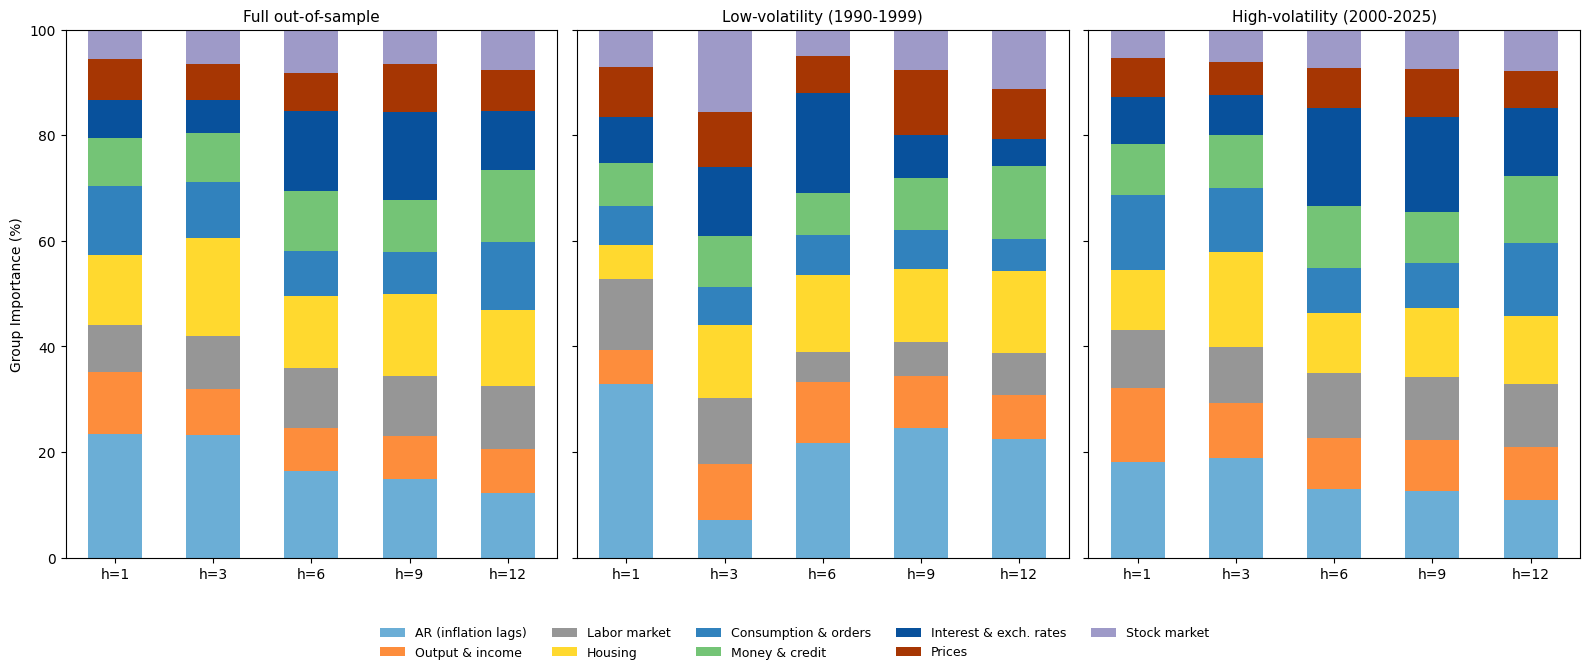

In [ ]:
# ============================================================
# VARIABLE IMPORTANCE — STACKED BAR CHARTS (Huang Fig. E11 style)
# One chart per period; each bar = one horizon; segments = group shares.
# ============================================================
import matplotlib.pyplot as plt
# Fixed group order + colors so all three charts are comparable
GROUP_ORDER = ["AR (inflation lags)", "Output & income", "Labor market",
               "Housing", "Consumption & orders", "Money & credit",
               "Interest & exch. rates", "Prices", "Stock market"]
COLORS = ["#6baed6", "#fd8d3c", "#969696", "#ffd92f", "#3182bd",
          "#74c476", "#08519c", "#a63603", "#9e9ac8"]
PERIODS = {"Full out-of-sample": ("1990-01-01", "2025-09-01"),
           "Low-volatility (1990-1999)": LOW_VOL,
           "High-volatility (2000-2025)": HIGH_VOL}
fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharey=True)
for ax, (label, (s, e)) in zip(axes, PERIODS.items()):
    # Build group-importance table: rows = groups, cols = horizons
    tab = {}
    for h in horizons:
        group_imp, _ = rf_group_importance(df_lags, pred_cols, h, s, e)
        tab[f"h={h}"] = group_imp
    tab = pd.DataFrame(tab).reindex(GROUP_ORDER).fillna(0)
    # Normalize each column to PERCENTAGES (each bar sums to 100%)
    shares = tab.div(tab.sum(axis=0), axis=1) * 100
    # Stacked bars
    bottom = np.zeros(len(shares.columns))
    for grp, color in zip(GROUP_ORDER, COLORS):
        ax.bar(shares.columns, shares.loc[grp], bottom=bottom,
               color=color, width=0.55, label=grp)
        bottom += shares.loc[grp].values
    ax.set_title(label, fontsize=11)
    ax.set_ylim(0, 100)
# Y-axis label on the leftmost panel only
axes[0].set_ylabel("Group Importance (%)")
# One shared legend below all three charts
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=9, frameon=False)
# fig.suptitle("Variable Importance: U.S. CPI Inflation (Random Forest)",
#              fontsize=13, weight="bold")
plt.tight_layout(rect=[0, 0.10, 1, 0.96])   # leave room for legend
plt.show()

In [ ]:
# ============================================================
# VARIABLE IMPORTANCE TABLES (Huang Table 14 / 16 style)
# Group importance as % shares per horizon, + Avg + Rank.
# Based on Random Forest (best model for CPI).
# ============================================================
import pandas as pd
import numpy as np

GROUP_ORDER = ["AR (inflation lags)", "Output & income", "Labor market",
               "Housing", "Consumption & orders", "Money & credit",
               "Interest & exch. rates", "Prices", "Stock market"]

def importance_percent_table(start, end):
    """Group importance as % of each horizon, with Avg and Rank columns."""
    # rows = groups, cols = horizons (raw within-group mean importance)
    raw = {}
    for h in horizons:
        group_imp, _ = rf_group_importance(df_lags, pred_cols, h, start, end)
        raw[f"h={h}"] = group_imp
    tab = pd.DataFrame(raw).reindex(GROUP_ORDER).fillna(0)

    # Normalize each horizon column to percentages (sums to 100%)
    pct = tab.div(tab.sum(axis=0), axis=1) * 100

    # Avg across horizons, then Rank (1 = most important)
    pct["Avg"] = pct.mean(axis=1)
    pct["Rank"] = pct["Avg"].rank(ascending=False).astype(int)
    return pct.round(1)

PERIODS = {
    "TABLE — FULL SAMPLE":            ("1990-01-01", "2025-09-01"),
    "TABLE — HIGH VOLATILITY (2000-2025)": HIGH_VOL,
    "TABLE — LOW VOLATILITY (1990-1999)":  LOW_VOL,
}

for title, (s, e) in PERIODS.items():
    print(f"\n===== {title} =====")
    print(f"(RF group importance, % per horizon)\n")
    print(importance_percent_table(s, e).to_string())


===== TABLE — FULL SAMPLE =====
(RF group importance, % per horizon)

                         h=1   h=3   h=6   h=9  h=12   Avg  Rank
AR (inflation lags)     23.5  23.2  16.5  14.9  12.2  18.0     1
Output & income         11.7   8.7   8.0   8.2   8.2   9.0     7
Labor market             8.9  10.1  11.3  11.3  12.1  10.7     4
Housing                 13.3  18.6  13.7  15.5  14.3  15.1     2
Consumption & orders    13.0  10.5   8.5   8.1  13.0  10.6     6
Money & credit           9.0   9.3  11.5   9.7  13.6  10.6     5
Interest & exch. rates   7.2   6.2  15.0  16.8  11.1  11.3     3
Prices                   7.8   7.0   7.3   9.1   7.8   7.8     8
Stock market             5.6   6.5   8.2   6.4   7.7   6.9     9

===== TABLE — HIGH VOLATILITY (2000-2025) =====
(RF group importance, % per horizon)

                         h=1   h=3   h=6   h=9  h=12   Avg  Rank
AR (inflation lags)     18.1  18.8  13.0  12.7  10.8  14.7     1
Output & income         13.9  10.4   9.6   9.5  10.0  10.7    

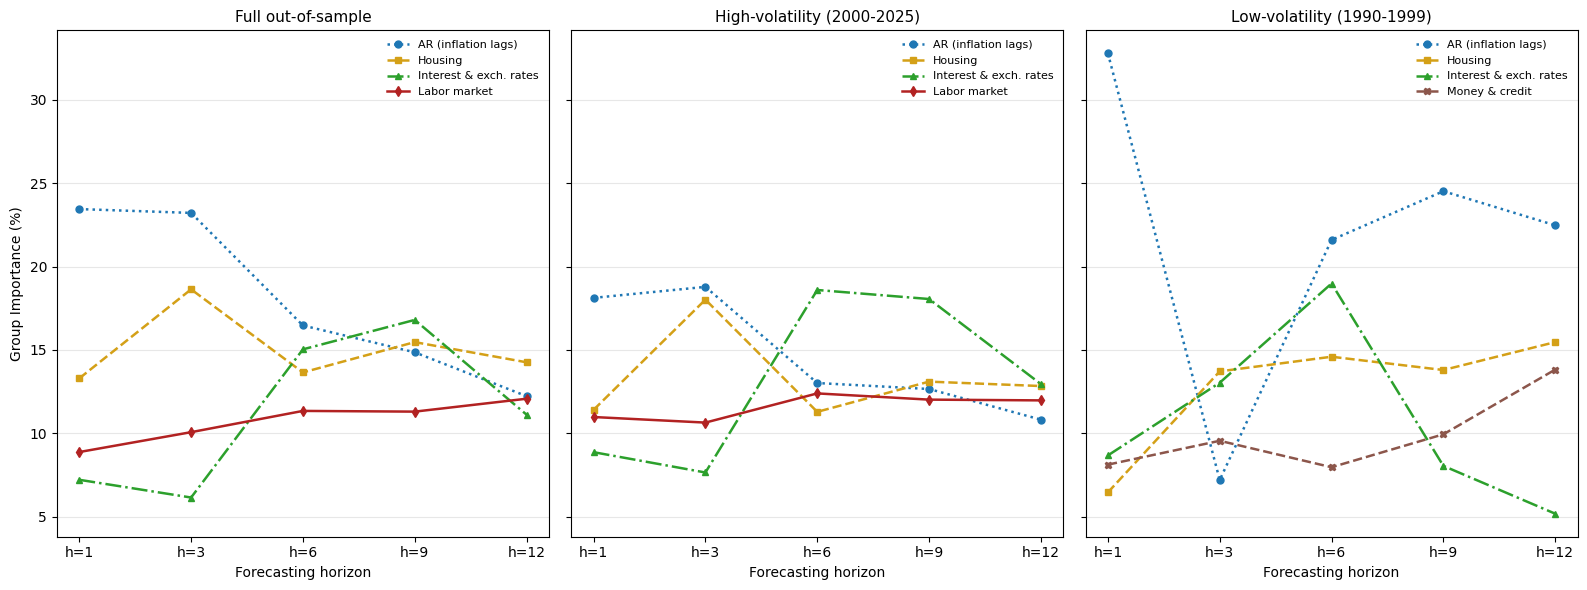

In [ ]:
# ============================================================
# VARIABLE IMPORTANCE — LINE CHARTS (Huang Fig. E14 style)
# Each panel shows ITS OWN four most important groups.
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

GROUP_ORDER = ["AR (inflation lags)", "Output & income", "Labor market",
               "Housing", "Consumption & orders", "Money & credit",
               "Interest & exch. rates", "Prices", "Stock market"]

# Fixed color + style PER GROUP, so a group looks the same in every panel it appears in
STYLE = {
    "AR (inflation lags)":   {"color": "#1f77b4", "ls": ":",  "marker": "o"},
    "Output & income":       {"color": "#ff7f0e", "ls": "-",  "marker": "v"},
    "Labor market":          {"color": "#b22222", "ls": "-",  "marker": "d"},
    "Housing":               {"color": "#d4a017", "ls": "--", "marker": "s"},
    "Consumption & orders":  {"color": "#9467bd", "ls": "-",  "marker": "P"},
    "Money & credit":        {"color": "#8c564b", "ls": "--", "marker": "X"},
    "Interest & exch. rates":{"color": "#2ca02c", "ls": "-.", "marker": "^"},
    "Prices":                {"color": "#e377c2", "ls": "-",  "marker": "*"},
    "Stock market":          {"color": "#7f7f7f", "ls": "-",  "marker": "h"},
}

def pct_table(start, end):
    """Group importance as % per horizon (columns sum to 100%)."""
    raw = {}
    for h in horizons:
        group_imp, _ = rf_group_importance(df_lags, pred_cols, h, start, end)
        raw[f"h={h}"] = group_imp
    tab = pd.DataFrame(raw).reindex(GROUP_ORDER).fillna(0)
    return tab.div(tab.sum(axis=0), axis=1) * 100

PERIODS = {"Full out-of-sample": ("1990-01-01", "2025-09-01"),
           "High-volatility (2000-2025)": HIGH_VOL,
           "Low-volatility (1990-1999)": LOW_VOL}

tables = {label: pct_table(s, e) for label, (s, e) in PERIODS.items()}

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

for ax, (label, tab) in zip(axes, tables.items()):
    # THIS panel's own top-4 groups by average importance across horizons
    top4 = tab.mean(axis=1).sort_values(ascending=False).head(4).index.tolist()
    for grp in top4:
        ax.plot(tab.columns, tab.loc[grp], label=grp, lw=1.8,
                color=STYLE[grp]["color"], ls=STYLE[grp]["ls"],
                marker=STYLE[grp]["marker"], markersize=5)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Forecasting horizon")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8, frameon=False)   # per-panel legend (groups differ)

axes[0].set_ylabel("Group Importance (%)")
plt.tight_layout()
plt.show()